# Klasyfikacja kart

Dataset: Cards Image Dataset

Cel:
- porownanie kilku CNN od zera
- sprawdzenie augmentacji i strojenia hiperparametrow
- porownanie z transfer learning
- ocena na zbiorze testowym
- wizualizacje i analiza bledow

## 1. Importy

In [1]:
import os
import gc
import json
import random
import warnings
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import VGG16, ResNet50, MobileNetV2, EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from sklearn.metrics import confusion_matrix, classification_report

warnings.filterwarnings("ignore", category=UserWarning)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("Python ok")
print("TensorFlow:", tf.__version__)

I0000 00:00:1775288375.753215     620 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Python ok
TensorFlow: 2.21.0


## 2. GPU i sciezki

In [2]:
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("GPU:", gpus[0].name)
else:
    print("GPU not found")

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "../data/cards-image-datasetclassification"
TRAIN_DIR = DATA_DIR / "train"
VALID_DIR = DATA_DIR / "valid"
TEST_DIR = DATA_DIR / "test"

RESULTS_DIR = BASE_DIR / "results"
CHECKPOINTS_DIR = RESULTS_DIR / "checkpoints"
PLOTS_DIR = RESULTS_DIR / "plots"
LOGS_DIR = RESULTS_DIR / "logs"
HISTORY_DIR = RESULTS_DIR / "histories"

for directory in [RESULTS_DIR, CHECKPOINTS_DIR, PLOTS_DIR, LOGS_DIR, HISTORY_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_CHANNELS = 3
IMG_SIZE = (IMG_HEIGHT, IMG_WIDTH)

SEARCH_BATCH_SIZE = 24
FINAL_BATCH_SIZE = 24
TRANSFER_BATCH_SIZE = 16

SEARCH_EPOCHS = 12
FINAL_EPOCHS = 35
TRANSFER_EPOCHS = 18

SEARCH_PATIENCE = 4
FINAL_PATIENCE = 7
TRANSFER_PATIENCE = 5

NUM_CLASSES_FALLBACK = 53

print("DATA_DIR:", DATA_DIR.resolve())
print("IMG_SIZE:", IMG_SIZE)
print("batch search:", SEARCH_BATCH_SIZE)
print("batch final:", FINAL_BATCH_SIZE)
print("batch transfer:", TRANSFER_BATCH_SIZE)
print("epochs:", SEARCH_EPOCHS, FINAL_EPOCHS, TRANSFER_EPOCHS)


GPU: /physical_device:GPU:0
DATA_DIR: /home/chemik/studia/ggsn/agh_ggsn/data/cards-image-datasetclassification
IMG_SIZE: (224, 224)
batch search: 24
batch final: 24
batch transfer: 16
epochs: 12 35 18


## 3a. Ustawienia treningu

Liczba epok jest wieksza niz w poprzedniej wersji.
Early stopping zatrzyma trening, gdy walidacja przestanie sie poprawiac.
Batch size zostaje umiarkowany, zeby nie przekroczyc pamieci GPU.


## 3. Lista plikow

In [3]:
def build_dataframe(split_dir):
    rows = []
    if not split_dir.exists():
        return pd.DataFrame(columns=["filepath", "label"])
    class_dirs = sorted([d for d in split_dir.iterdir() if d.is_dir()])
    for class_dir in class_dirs:
        for ext in ("*.jpg", "*.png", "*.jpeg", "*.webp"):
            for file_path in class_dir.glob(ext):
                rows.append({"filepath": str(file_path), "label": class_dir.name})
    return pd.DataFrame(rows)

train_df = build_dataframe(TRAIN_DIR)
valid_df = build_dataframe(VALID_DIR)
test_df = build_dataframe(TEST_DIR)

if train_df.empty:
    raise FileNotFoundError(f"Brak danych treningowych w: {TRAIN_DIR}")

class_names = sorted(train_df["label"].unique().tolist())
NUM_CLASSES = len(class_names) if class_names else NUM_CLASSES_FALLBACK
class_to_idx = {name: idx for idx, name in enumerate(class_names)}
idx_to_class = {idx: name for name, idx in class_to_idx.items()}

print("train:", len(train_df))
print("valid:", len(valid_df))
print("test:", len(test_df))
print("classes:", NUM_CLASSES)

with open(RESULTS_DIR / "class_indices.json", "w", encoding="utf-8") as f:
    json.dump(class_to_idx, f, indent=2, ensure_ascii=False)

train: 7624
valid: 265
test: 265
classes: 53


## 4. Rozklad klas

min: 108
max: 181
mean: 143.85


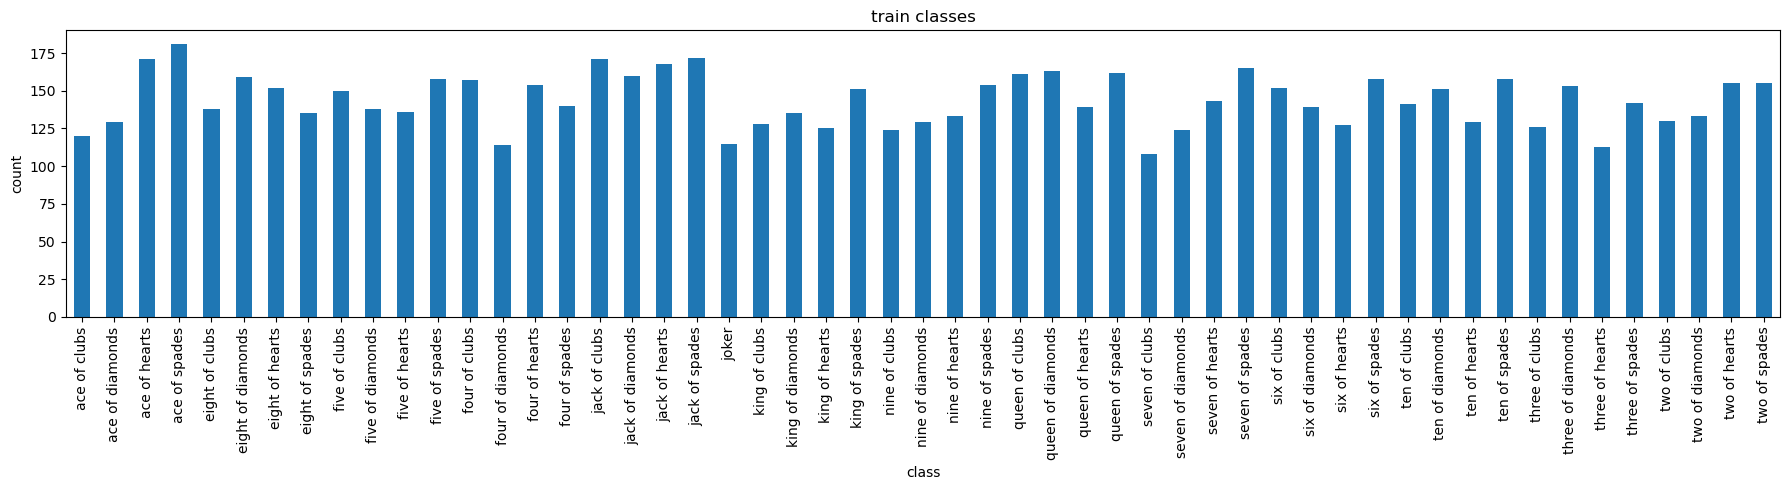

In [4]:
train_counts = train_df["label"].value_counts().sort_index()

print("min:", int(train_counts.min()))
print("max:", int(train_counts.max()))
print("mean:", round(float(train_counts.mean()), 2))

plt.figure(figsize=(18, 5))
train_counts.plot(kind="bar")
plt.xlabel("class")
plt.ylabel("count")
plt.title("train classes")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "train_classes.png", dpi=140, bbox_inches="tight")
plt.show()

## 5. Przykladowe obrazy

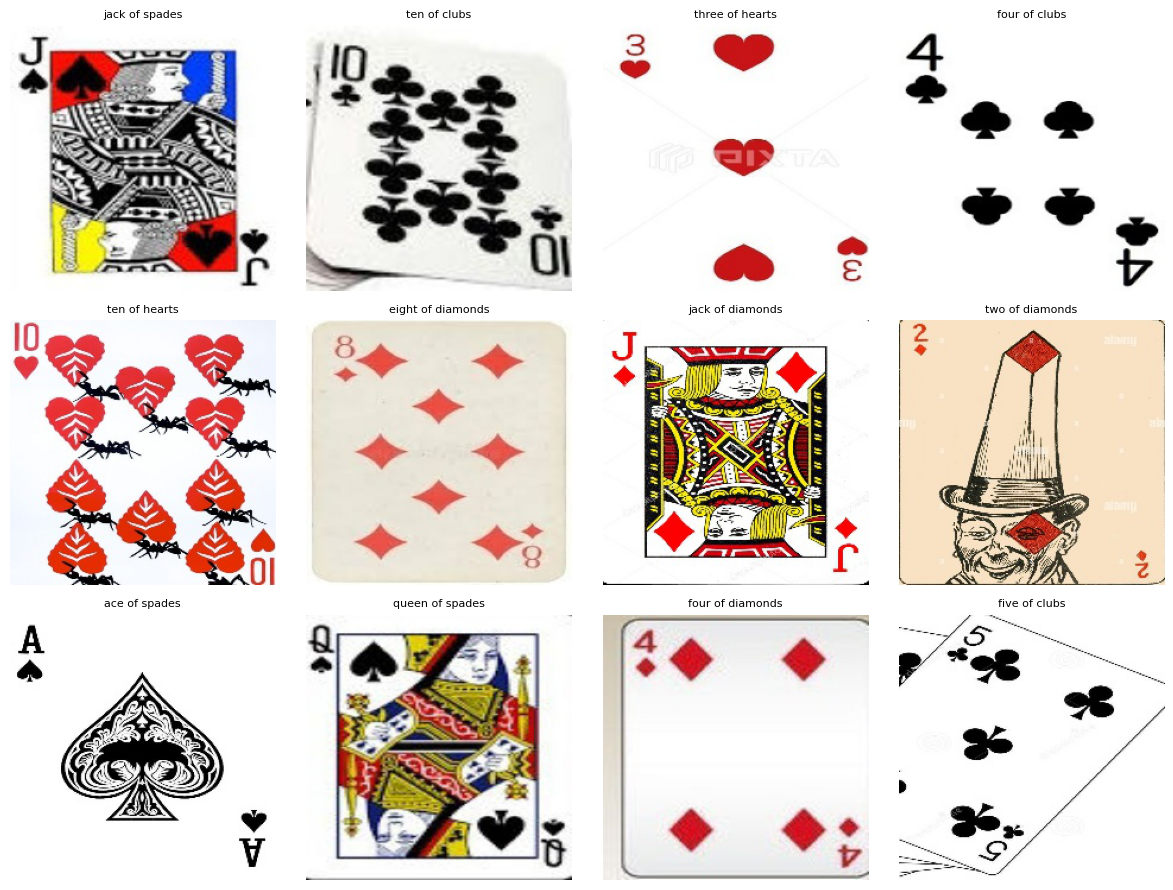

In [5]:
sample_labels = np.random.choice(class_names, size=min(12, len(class_names)), replace=False)

fig, axes = plt.subplots(3, 4, figsize=(12, 9))
axes = axes.ravel()

for ax, label in zip(axes, sample_labels):
    sample_path = train_df.loc[train_df["label"] == label, "filepath"].sample(1, random_state=SEED).iloc[0]
    img = load_img(sample_path, target_size=IMG_SIZE)
    ax.imshow(img)
    ax.set_title(label, fontsize=8)
    ax.axis("off")

for i in range(len(sample_labels), len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.savefig(PLOTS_DIR / "sample_images.png", dpi=140, bbox_inches="tight")
plt.show()

## 6. Podzial do szybkiego strojenia

Na etapie przeszukiwania architektur uzywamy mniejszej probki danych i mniejszej liczby epok.
To przyspiesza porownanie struktur i wartosci parametrów.

Na koncu wybrana konfiguracja jest trenowana ponownie na calym zbiorze treningowym.
Test pozostaje nietkniety do finalnej oceny.

In [6]:
def stratified_sample(df, frac, seed=SEED):
    frac = float(frac)
    if frac >= 0.999:
        return df.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    sampled = (
        df.groupby("label", group_keys=False)
          .apply(lambda x: x.sample(max(1, int(np.ceil(len(x) * frac))), random_state=seed))
          .reset_index(drop=True)
    )
    return sampled

search_train_df = stratified_sample(train_df, 0.35)
search_valid_df = stratified_sample(valid_df, 0.60) if not valid_df.empty else valid_df.copy()

print("search train:", len(search_train_df))
print("search valid:", len(search_valid_df))

search train: 2694
search valid: 159


/tmp/ipykernel_620/986790094.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(max(1, int(np.ceil(len(x) * frac))), random_state=seed))
/tmp/ipykernel_620/986790094.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(max(1, int(np.ceil(len(x) * frac))), random_state=seed))


## 7. Generatory danych

In [7]:
def make_datagens(preprocess_fn=None, augment=False, raw_input=False):
    train_args = {}
    eval_args = {}
    if preprocess_fn is None:
        if not raw_input:
            train_args["rescale"] = 1.0 / 255.0
            eval_args["rescale"] = 1.0 / 255.0
    else:
        train_args["preprocessing_function"] = preprocess_fn
        eval_args["preprocessing_function"] = preprocess_fn

    if augment:
        train_args.update(
            rotation_range=15,
            width_shift_range=0.10,
            height_shift_range=0.10,
            zoom_range=0.10,
            shear_range=0.10,
            horizontal_flip=True,
            fill_mode="nearest",
        )

    return ImageDataGenerator(**train_args), ImageDataGenerator(**eval_args), ImageDataGenerator(**eval_args)

def make_generators(train_data, valid_data, test_data=None, batch_size=24, preprocess_fn=None, augment=False, raw_input=False):
    train_gen_obj, valid_gen_obj, test_gen_obj = make_datagens(preprocess_fn=preprocess_fn, augment=augment, raw_input=raw_input)

    train_gen = train_gen_obj.flow_from_dataframe(
        train_data,
        x_col="filepath",
        y_col="label",
        target_size=IMG_SIZE,
        class_mode="categorical",
        batch_size=batch_size,
        shuffle=True,
        seed=SEED,
    )

    valid_gen = None
    if valid_data is not None and len(valid_data) > 0:
        valid_gen = valid_gen_obj.flow_from_dataframe(
            valid_data,
            x_col="filepath",
            y_col="label",
            target_size=IMG_SIZE,
            class_mode="categorical",
            batch_size=batch_size,
            shuffle=False,
        )

    test_gen = None
    if test_data is not None and len(test_data) > 0:
        test_gen = test_gen_obj.flow_from_dataframe(
            test_data,
            x_col="filepath",
            y_col="label",
            target_size=IMG_SIZE,
            class_mode="categorical",
            batch_size=batch_size,
            shuffle=False,
        )

    return train_gen, valid_gen, test_gen

## 8. Podglad augmentacji

Found 2694 validated image filenames belonging to 53 classes.
Found 159 validated image filenames belonging to 53 classes.


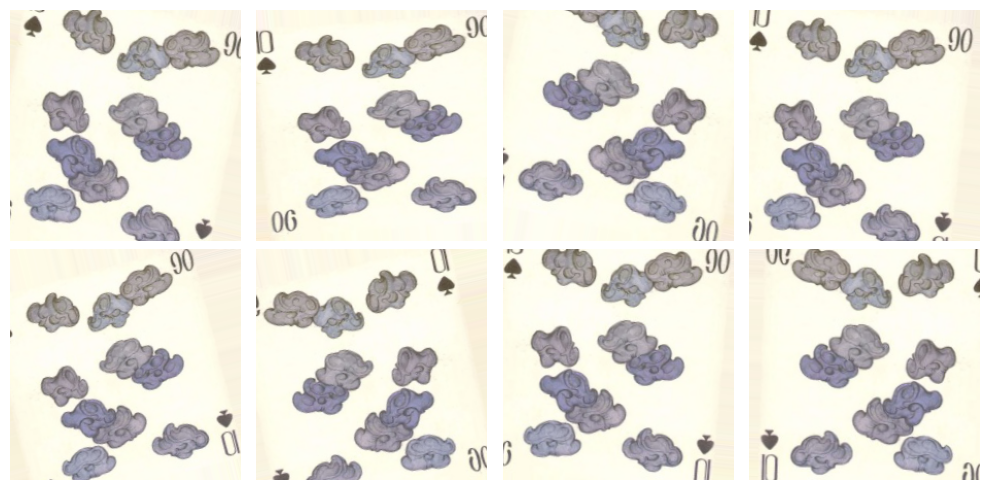

60

In [8]:
aug_train_gen, _, _ = make_generators(
    search_train_df,
    search_valid_df,
    None,
    batch_size=1,
    preprocess_fn=None,
    augment=True,
)

sample_path = search_train_df.sample(1, random_state=SEED)["filepath"].iloc[0]
sample_img = load_img(sample_path, target_size=IMG_SIZE)
sample_arr = np.expand_dims(img_to_array(sample_img), axis=0)

preview_gen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    shear_range=0.10,
    horizontal_flip=True,
    fill_mode="nearest",
)

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
axes = axes.ravel()

for i, batch in enumerate(preview_gen.flow(sample_arr, batch_size=1, shuffle=False)):
    axes[i].imshow(batch[0])
    axes[i].axis("off")
    if i == 7:
        break

plt.tight_layout()
plt.savefig(PLOTS_DIR / "augmentation_preview.png", dpi=140, bbox_inches="tight")
plt.show()

del aug_train_gen
gc.collect()

## 9. Funkcje pomocnicze

In [9]:
def clear_memory():
    keras.backend.clear_session()
    gc.collect()

def make_callbacks(model_name, patience=4):
    return [
        ModelCheckpoint(
            filepath=str(CHECKPOINTS_DIR / f"{model_name}.keras"),
            monitor="val_accuracy",
            mode="max",
            save_best_only=True,
            verbose=1,
        ),
        EarlyStopping(
            monitor="val_loss",
            patience=patience,
            min_delta=1e-4,
            restore_best_weights=True,
            verbose=1,
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=max(2, patience // 2),
            min_lr=1e-6,
            verbose=1,
        ),
        CSVLogger(str(LOGS_DIR / f"{model_name}.csv")),
    ]

def plot_history(history, title, save_name):
    hist_df = pd.DataFrame(history.history)
    hist_df["epoch"] = np.arange(1, len(hist_df) + 1)
    hist_df.to_csv(HISTORY_DIR / f"{save_name}.csv", index=False)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].plot(hist_df["epoch"], hist_df["accuracy"], label="train")
    axes[0].plot(hist_df["epoch"], hist_df["val_accuracy"], label="valid")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("acc")
    axes[0].set_title("acc")
    axes[0].legend()

    axes[1].plot(hist_df["epoch"], hist_df["loss"], label="train")
    axes[1].plot(hist_df["epoch"], hist_df["val_loss"], label="valid")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylabel("loss")
    axes[1].set_title("loss")
    axes[1].legend()

    plt.suptitle(title)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"{save_name}.png", dpi=140, bbox_inches="tight")
    plt.show()

def evaluate_model(model, generator, model_name):
    loss, acc = model.evaluate(generator, verbose=0)
    print(f"{model_name}: acc={acc:.4f}, loss={loss:.4f}")
    return {"model": model_name, "accuracy": float(acc), "loss": float(loss)}

def load_saved_model(model_path):
    return keras.models.load_model(model_path)


## 10. Architektury CNN

In [10]:
def cnn_small(num_classes, dropout=0.30):
    model = keras.Sequential([
        layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)),
        layers.Conv2D(32, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(num_classes, activation="softmax"),
    ])
    return model

def cnn_bn_gap(num_classes, dropout=0.35):
    model = keras.Sequential([
        layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)),
        layers.Conv2D(32, 3, padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(),
        layers.Dropout(0.15),

        layers.Conv2D(64, 3, padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(),
        layers.Dropout(0.20),

        layers.Conv2D(128, 3, padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        layers.Conv2D(192, 3, padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.GlobalAveragePooling2D(),
        layers.Dense(192, activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(num_classes, activation="softmax"),
    ])
    return model

def cnn_separable(num_classes, dropout=0.30):
    inputs = layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
    x = layers.Rescaling(1.0 / 255.0)(inputs)
    for filters in [32, 64, 128, 192]:
        x = layers.SeparableConv2D(filters, 3, padding="same", use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        x = layers.MaxPooling2D()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(192, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return Model(inputs, outputs, name="cnn_separable")

def residual_block(x, filters, stride=1):
    shortcut = x
    x = layers.Conv2D(filters, 3, strides=stride, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)

    if shortcut.shape[-1] != filters or stride != 1:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding="same", use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.Activation("relu")(x)
    return x

def cnn_residual_light(num_classes, dropout=0.30):
    inputs = layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
    x = layers.Rescaling(1.0 / 255.0)(inputs)
    x = layers.Conv2D(32, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = residual_block(x, 32)
    x = layers.MaxPooling2D()(x)
    x = residual_block(x, 64)
    x = layers.MaxPooling2D()(x)
    x = residual_block(x, 128)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return Model(inputs, outputs, name="cnn_residual_light")

CNN_BUILDERS = {
    "cnn_small": cnn_small,
    "cnn_bn_gap": cnn_bn_gap,
    "cnn_separable": cnn_separable,
    "cnn_residual_light": cnn_residual_light,
}

## 11. Konfiguracje CNN

Sprawdzamy rozne struktury i parametry:
- klasyczny CNN
- CNN z BN i GAP
- separable CNN
- lekki CNN rezydualny
- rozne learning rate
- rozne dropout
- label smoothing

In [11]:
cnn_search_configs = [
    {"name": "cnn_small_lr1e3", "builder": "cnn_small", "lr": 1e-3, "dropout": 0.30, "label_smoothing": 0.00},
    {"name": "cnn_small_lr3e4", "builder": "cnn_small", "lr": 3e-4, "dropout": 0.35, "label_smoothing": 0.05},
    {"name": "cnn_bn_gap_lr1e3", "builder": "cnn_bn_gap", "lr": 1e-3, "dropout": 0.35, "label_smoothing": 0.05},
    {"name": "cnn_bn_gap_lr3e4", "builder": "cnn_bn_gap", "lr": 3e-4, "dropout": 0.40, "label_smoothing": 0.05},
    {"name": "cnn_separable_lr1e3", "builder": "cnn_separable", "lr": 1e-3, "dropout": 0.30, "label_smoothing": 0.05},
    {"name": "cnn_residual_lr3e4", "builder": "cnn_residual_light", "lr": 3e-4, "dropout": 0.30, "label_smoothing": 0.05},
]

pd.DataFrame(cnn_search_configs)

,name,builder,lr,dropout,label_smoothing
0,cnn_small_lr1e3,cnn_small,0.0010,0.30,0.00
1,cnn_small_lr3e4,cnn_small,0.0003,0.35,0.05
2,cnn_bn_gap_lr1e3,cnn_bn_gap,0.0010,0.35,0.05
3,cnn_bn_gap_lr3e4,cnn_bn_gap,0.0003,0.40,0.05
4,cnn_separable_lr1e3,cnn_separable,0.0010,0.30,0.05
5,cnn_residual_lr3e4,cnn_residual_light,0.0003,0.30,0.05


## 12. Strojenie CNN na mniejszej probce

Start: cnn_small_lr1e3
Found 2694 validated image filenames belonging to 53 classes.
Found 159 validated image filenames belonging to 53 classes.


I0000 00:00:1775288385.584295     620 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5561 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060, pci bus id: 0000:0a:00.0, compute capability: 8.9


Epoch 1/12


I0000 00:00:1775288387.600825     620 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1775288389.473018     710 service.cc:153] XLA service 0x7d95c4005a00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775288389.473074     710 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060, Compute Capability 8.9 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1775288389.542606     710 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1775288389.915850     710 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1775288389.987767     710 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2062__.44
I0000 00:00:1775288392.554214     710 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set

  2/113 ━━━━━━━━━━━━━━━━━━━━ 10s 93ms/step - accuracy: 0.0000e+00 - loss: 4.2858 

...

 87/113 ━━━━━━━━━━━━━━━━━━━━ 8s 310ms/step - accuracy: 0.0146 - loss: 4.0260

I0000 00:00:1775288429.835751     710 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2062__.44


113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 0.0172 - loss: 4.0047

I0000 00:00:1775288446.666402     712 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.



Epoch 1: val_accuracy improved from None to 0.10063, saving model to /home/chemik/studia/ggsn/agh_ggsn/ex2/results/checkpoints/cnn_small_lr1e3.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 67s 462ms/step - accuracy: 0.0290 - loss: 3.9136 - val_accuracy: 0.1006 - val_loss: 3.3584 - learning_rate: 0.0010
Epoch 2/12
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step - accuracy: 0.0948 - loss: 3.5493
Epoch 2: val_accuracy improved from 0.10063 to 0.24528, saving model to /home/chemik/studia/ggsn/agh_ggsn/ex2/results/checkpoints/cnn_small_lr1e3.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 34s 297ms/step - accuracy: 0.1154 - loss: 3.4087 - val_accuracy: 0.2453 - val_loss: 2.5460 - learning_rate: 0.0010
Epoch 3/12
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - accuracy: 0.1748 - loss: 3.0811
Epoch 3: val_accuracy improved from 0.24528 to 0.33962, saving model to /home/chemik/studia/ggsn/agh_ggsn/ex2/results/checkpoints/cnn_small_lr1e3.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 31s 270ms/step - accuracy: 0.1811 - loss: 3.0476 - va

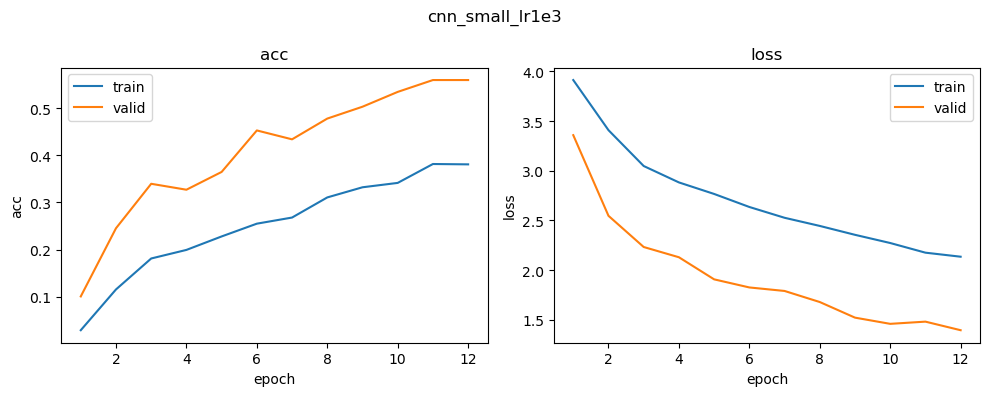

Start: cnn_small_lr3e4
Found 2694 validated image filenames belonging to 53 classes.
Found 159 validated image filenames belonging to 53 classes.
Epoch 1/12


I0000 00:00:1775288796.463016     709 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_11550__.44


 69/113 ━━━━━━━━━━━━━━━━━━━━ 11s 261ms/step - accuracy: 0.0235 - loss: 4.0412

I0000 00:00:1775288818.059226     712 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_11550__.44


113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - accuracy: 0.0267 - loss: 4.0094
Epoch 1: val_accuracy improved from None to 0.12579, saving model to /home/chemik/studia/ggsn/agh_ggsn/ex2/results/checkpoints/cnn_small_lr3e4.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 42s 324ms/step - accuracy: 0.0364 - loss: 3.9419 - val_accuracy: 0.1258 - val_loss: 3.6558 - learning_rate: 3.0000e-04
Epoch 2/12
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 0.0872 - loss: 3.7502
Epoch 2: val_accuracy improved from 0.12579 to 0.22013, saving model to /home/chemik/studia/ggsn/agh_ggsn/ex2/results/checkpoints/cnn_small_lr3e4.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 29s 253ms/step - accuracy: 0.1036 - loss: 3.6874 - val_accuracy: 0.2201 - val_loss: 3.1551 - learning_rate: 3.0000e-04
Epoch 3/12
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy: 0.1371 - loss: 3.4931
Epoch 3: val_accuracy improved from 0.22013 to 0.27673, saving model to /home/chemik/studia/ggsn/agh_ggsn/ex2/results/checkpoints/cnn_small_lr3e4.kera

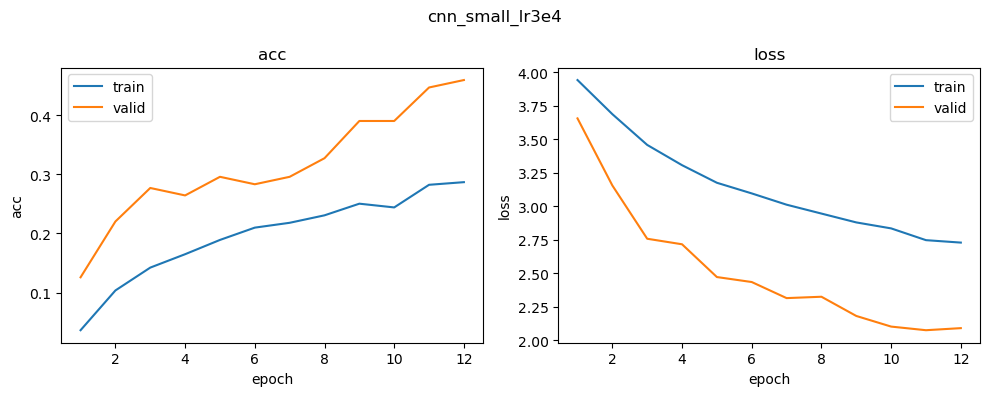

Start: cnn_bn_gap_lr1e3
Found 2694 validated image filenames belonging to 53 classes.
Found 159 validated image filenames belonging to 53 classes.
Epoch 1/12


I0000 00:00:1775289170.086694     709 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_23319__.72
I0000 00:00:1775289170.750453     709 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1775289172.914500    3211 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_6', 4 bytes spill stores, 4 bytes spill loads



 15/113 ━━━━━━━━━━━━━━━━━━━━ 25s 257ms/step - accuracy: 0.0073 - loss: 4.0946

I0000 00:00:1775289191.635110     709 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_23319__.72
I0000 00:00:1775289197.777854    3375 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_add_reduce_fusion_3', 232 bytes spill stores, 232 bytes spill loads

I0000 00:00:1775289208.136833     709 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_add_reduce_fusion_3', 240 bytes spill stores, 240 bytes spill loads



113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.0301 - loss: 3.9219

I0000 00:00:1775289234.963314     712 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.



Epoch 1: val_accuracy improved from None to 0.01887, saving model to /home/chemik/studia/ggsn/agh_ggsn/ex2/results/checkpoints/cnn_bn_gap_lr1e3.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 75s 479ms/step - accuracy: 0.0434 - loss: 3.7887 - val_accuracy: 0.0189 - val_loss: 4.1981 - learning_rate: 0.0010
Epoch 2/12
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - accuracy: 0.0698 - loss: 3.5496
Epoch 2: val_accuracy improved from 0.01887 to 0.03145, saving model to /home/chemik/studia/ggsn/agh_ggsn/ex2/results/checkpoints/cnn_bn_gap_lr1e3.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 30s 266ms/step - accuracy: 0.0742 - loss: 3.5176 - val_accuracy: 0.0314 - val_loss: 3.9951 - learning_rate: 0.0010
Epoch 3/12
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - accuracy: 0.0871 - loss: 3.4125
Epoch 3: val_accuracy did not improve from 0.03145
113/113 ━━━━━━━━━━━━━━━━━━━━ 27s 239ms/step - accuracy: 0.0857 - loss: 3.4173 - val_accuracy: 0.0314 - val_loss: 3.8831 - learning_rate: 0.0010
Epoch 4/12
113/113 ━━━━━━━━━━━━━━━━━━

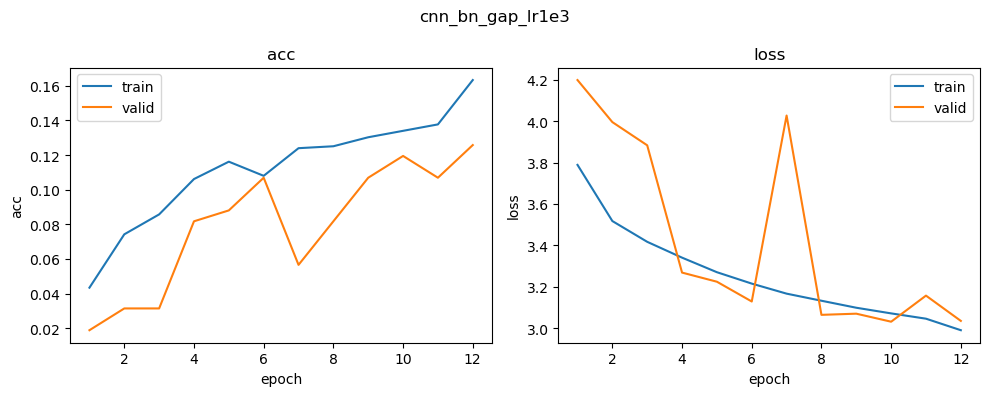

Start: cnn_bn_gap_lr3e4
Found 2694 validated image filenames belonging to 53 classes.
Found 159 validated image filenames belonging to 53 classes.
Epoch 1/12


I0000 00:00:1775289580.452760     711 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_36038__.72


102/113 ━━━━━━━━━━━━━━━━━━━━ 2s 250ms/step - accuracy: 0.0283 - loss: 3.9893

I0000 00:00:1775289614.287006     711 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_36038__.72
I0000 00:00:1775289622.696230     711 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_add_reduce_fusion_3', 240 bytes spill stores, 240 bytes spill loads



113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step - accuracy: 0.0288 - loss: 3.9825
Epoch 1: val_accuracy improved from None to 0.03145, saving model to /home/chemik/studia/ggsn/agh_ggsn/ex2/results/checkpoints/cnn_bn_gap_lr3e4.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 52s 363ms/step - accuracy: 0.0338 - loss: 3.9146 - val_accuracy: 0.0314 - val_loss: 4.0306 - learning_rate: 3.0000e-04
Epoch 2/12
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - accuracy: 0.0673 - loss: 3.7092
Epoch 2: val_accuracy did not improve from 0.03145
113/113 ━━━━━━━━━━━━━━━━━━━━ 34s 296ms/step - accuracy: 0.0679 - loss: 3.6988 - val_accuracy: 0.0189 - val_loss: 4.0430 - learning_rate: 3.0000e-04
Epoch 3/12
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - accuracy: 0.0737 - loss: 3.5675
Epoch 3: val_accuracy did not improve from 0.03145
113/113 ━━━━━━━━━━━━━━━━━━━━ 29s 259ms/step - accuracy: 0.0702 - loss: 3.5574 - val_accuracy: 0.0314 - val_loss: 3.9056 - learning_rate: 3.0000e-04
Epoch 4/12
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/st

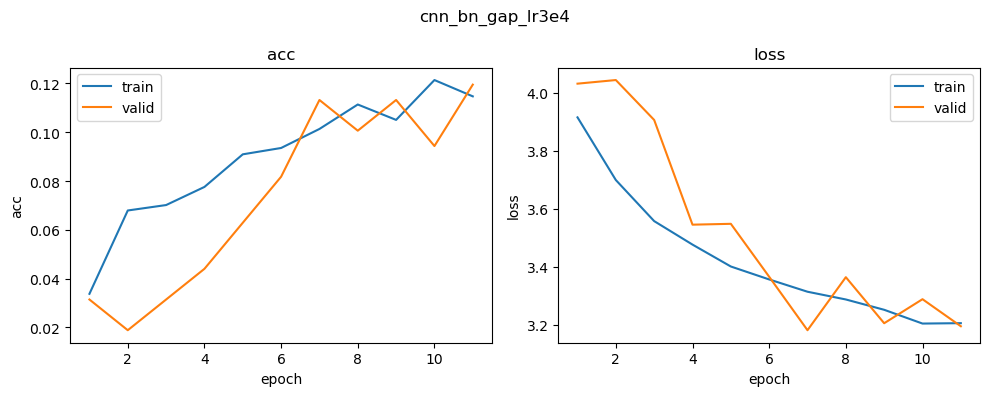

Start: cnn_separable_lr1e3
Found 2694 validated image filenames belonging to 53 classes.
Found 159 validated image filenames belonging to 53 classes.
Epoch 1/12


I0000 00:00:1775289932.262259     711 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_47724__.75


 34/113 ━━━━━━━━━━━━━━━━━━━━ 20s 263ms/step - accuracy: 0.0133 - loss: 3.9912

I0000 00:00:1775289959.805077     710 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_47724__.75


113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - accuracy: 0.0230 - loss: 3.9464
Epoch 1: val_accuracy improved from None to 0.01887, saving model to /home/chemik/studia/ggsn/agh_ggsn/ex2/results/checkpoints/cnn_separable_lr1e3.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 75s 480ms/step - accuracy: 0.0367 - loss: 3.8723 - val_accuracy: 0.0189 - val_loss: 3.9713 - learning_rate: 0.0010
Epoch 2/12
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - accuracy: 0.0623 - loss: 3.5883
Epoch 2: val_accuracy did not improve from 0.01887
113/113 ━━━━━━━━━━━━━━━━━━━━ 34s 301ms/step - accuracy: 0.0664 - loss: 3.5398 - val_accuracy: 0.0189 - val_loss: 3.9978 - learning_rate: 0.0010
Epoch 3/12
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step - accuracy: 0.0799 - loss: 3.4148
Epoch 3: val_accuracy did not improve from 0.01887

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
113/113 ━━━━━━━━━━━━━━━━━━━━ 28s 246ms/step - accuracy: 0.0794 - loss: 3.3971 - val_accuracy: 0.0189 - val_loss: 4.1239 - learn

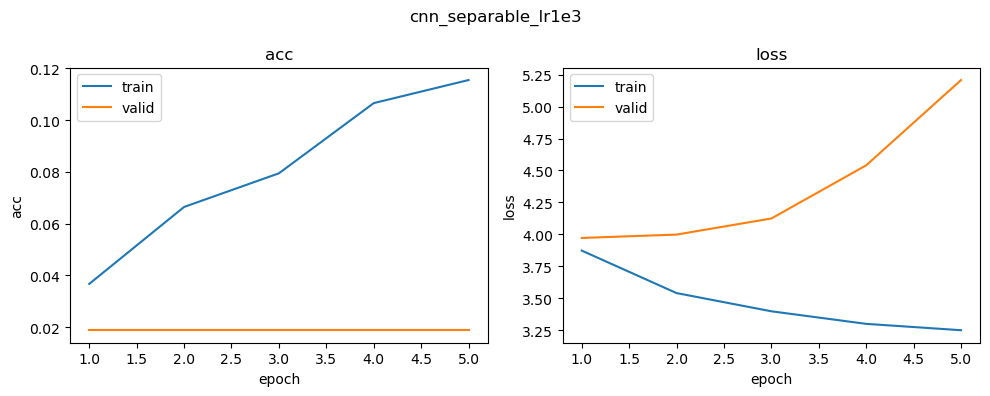

Start: cnn_residual_lr3e4
Found 2694 validated image filenames belonging to 53 classes.
Found 159 validated image filenames belonging to 53 classes.
Epoch 1/12


I0000 00:00:1775290129.960737     711 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_57484__.88


 94/113 ━━━━━━━━━━━━━━━━━━━━ 4s 261ms/step - accuracy: 0.0371 - loss: 4.0943

I0000 00:00:1775290172.656343     709 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_57484__.88


113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step - accuracy: 0.0382 - loss: 4.0729

I0000 00:00:1775290190.268378     710 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.



Epoch 1: val_accuracy improved from None to 0.01887, saving model to /home/chemik/studia/ggsn/agh_ggsn/ex2/results/checkpoints/cnn_residual_lr3e4.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 74s 459ms/step - accuracy: 0.0453 - loss: 3.9529 - val_accuracy: 0.0189 - val_loss: 4.0747 - learning_rate: 3.0000e-04
Epoch 2/12
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - accuracy: 0.0586 - loss: 3.7501
Epoch 2: val_accuracy did not improve from 0.01887
113/113 ━━━━━━━━━━━━━━━━━━━━ 35s 309ms/step - accuracy: 0.0586 - loss: 3.7311 - val_accuracy: 0.0189 - val_loss: 4.1550 - learning_rate: 3.0000e-04
Epoch 3/12
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - accuracy: 0.0640 - loss: 3.6497
Epoch 3: val_accuracy did not improve from 0.01887

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
113/113 ━━━━━━━━━━━━━━━━━━━━ 28s 251ms/step - accuracy: 0.0679 - loss: 3.6382 - val_accuracy: 0.0189 - val_loss: 4.2223 - learning_rate: 3.0000e-04
Epoch 4/12
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms

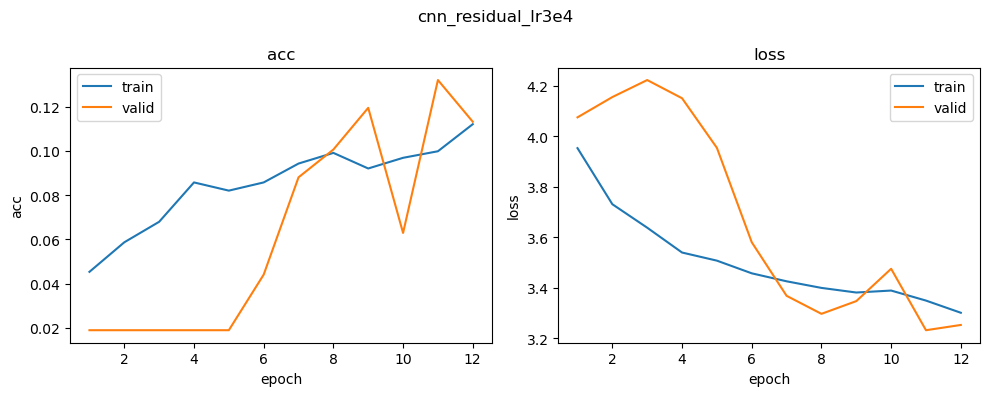

,name,builder,lr,dropout,label_smoothing,best_val_acc,best_epoch,val_loss_at_best,model_path
0,cnn_small_lr1e3,cnn_small,0.0010,0.30,0.00,0.559748,11,1.480031,/home/chemik/studia/ggsn/agh_ggsn/ex2/results/...
1,cnn_small_lr3e4,cnn_small,0.0003,0.35,0.05,0.459119,12,2.090468,/home/chemik/studia/ggsn/agh_ggsn/ex2/results/...
2,cnn_residual_lr3e4,cnn_residual_light,0.0003,0.30,0.05,0.132075,11,3.232706,/home/chemik/studia/ggsn/agh_ggsn/ex2/results/...
3,cnn_bn_gap_lr1e3,cnn_bn_gap,0.0010,0.35,0.05,0.125786,12,3.035663,/home/chemik/studia/ggsn/agh_ggsn/ex2/results/...
4,cnn_bn_gap_lr3e4,cnn_bn_gap,0.0003,0.40,0.05,0.119497,11,3.195592,/home/chemik/studia/ggsn/agh_ggsn/ex2/results/...
5,cnn_separable_lr1e3,cnn_separable,0.0010,0.30,0.05,0.018868,1,3.971347,/home/chemik/studia/ggsn/agh_ggsn/ex2/results/...


In [12]:
cnn_search_results = []

for cfg in cnn_search_configs:
    clear_memory()
    print("=" * 70)
    print("Start:", cfg["name"])
    print("=" * 70)

    train_gen, valid_gen, _ = make_generators(
        search_train_df,
        search_valid_df,
        None,
        batch_size=SEARCH_BATCH_SIZE,
        preprocess_fn=None,
        augment=True,
    )

    model = CNN_BUILDERS[cfg["builder"]](NUM_CLASSES, dropout=cfg["dropout"])
    loss_fn = keras.losses.CategoricalCrossentropy(label_smoothing=cfg["label_smoothing"])
    model.compile(
        optimizer=Adam(learning_rate=cfg["lr"]),
        loss=loss_fn,
        metrics=["accuracy"],
    )

    history = model.fit(
        train_gen,
        validation_data=valid_gen,
        epochs=SEARCH_EPOCHS,
        callbacks=make_callbacks(cfg["name"], patience=SEARCH_PATIENCE),
        verbose=1,
    )

    plot_history(history, cfg["name"], cfg["name"])

    best_val_acc = float(np.max(history.history["val_accuracy"]))
    best_epoch = int(np.argmax(history.history["val_accuracy"]) + 1)
    final_val_loss = float(history.history["val_loss"][best_epoch - 1])

    cnn_search_results.append({
        "name": cfg["name"],
        "builder": cfg["builder"],
        "lr": cfg["lr"],
        "dropout": cfg["dropout"],
        "label_smoothing": cfg["label_smoothing"],
        "best_val_acc": best_val_acc,
        "best_epoch": best_epoch,
        "val_loss_at_best": final_val_loss,
        "model_path": str(CHECKPOINTS_DIR / f"{cfg['name']}.keras"),
    })

    del model, history, train_gen, valid_gen
    gc.collect()

cnn_search_df = pd.DataFrame(cnn_search_results).sort_values(["best_val_acc", "val_loss_at_best"], ascending=[False, True]).reset_index(drop=True)
cnn_search_df.to_csv(RESULTS_DIR / "cnn_search_summary.csv", index=False)
cnn_search_df

## 13. Porownanie CNN

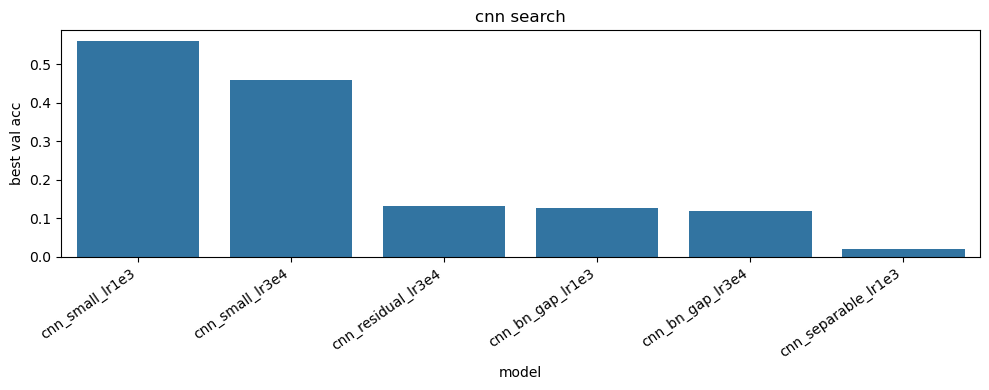

best cnn config:
{'name': 'cnn_small_lr1e3', 'builder': 'cnn_small', 'lr': 0.001, 'dropout': 0.3, 'label_smoothing': 0.0, 'best_val_acc': 0.5597484111785889, 'best_epoch': 11, 'val_loss_at_best': 1.4800306558609009, 'model_path': '/home/chemik/studia/ggsn/agh_ggsn/ex2/results/checkpoints/cnn_small_lr1e3.keras'}


In [13]:
plt.figure(figsize=(10, 4))
sns.barplot(data=cnn_search_df, x="name", y="best_val_acc")
plt.xticks(rotation=35, ha="right")
plt.xlabel("model")
plt.ylabel("best val acc")
plt.title("cnn search")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "cnn_search_bar.png", dpi=140, bbox_inches="tight")
plt.show()

best_cnn_cfg = cnn_search_df.iloc[0].to_dict()
print("best cnn config:")
print(best_cnn_cfg)

## 14. Finalny trening najlepszego CNN

Tutaj bierzemy najlepsza konfiguracje z poprzedniego kroku
i trenujemy ja od nowa na pelnym zbiorze treningowym.

Found 7624 validated image filenames belonging to 53 classes.
Found 265 validated image filenames belonging to 53 classes.
Epoch 1/35


I0000 00:00:1775290546.940217     709 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_68468__.44


279/318 ━━━━━━━━━━━━━━━━━━━━ 9s 253ms/step - accuracy: 0.0412 - loss: 4.0610 

I0000 00:00:1775290621.465840     710 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_68468__.44


318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step - accuracy: 0.0455 - loss: 4.0147
Epoch 1: val_accuracy improved from None to 0.21887, saving model to /home/chemik/studia/ggsn/agh_ggsn/ex2/results/checkpoints/best_cnn_full.keras
318/318 ━━━━━━━━━━━━━━━━━━━━ 102s 305ms/step - accuracy: 0.0788 - loss: 3.6586 - val_accuracy: 0.2189 - val_loss: 2.6939 - learning_rate: 0.0010
Epoch 2/35
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - accuracy: 0.1892 - loss: 3.0180
Epoch 2: val_accuracy improved from 0.21887 to 0.41132, saving model to /home/chemik/studia/ggsn/agh_ggsn/ex2/results/checkpoints/best_cnn_full.keras
318/318 ━━━━━━━━━━━━━━━━━━━━ 83s 260ms/step - accuracy: 0.2012 - loss: 2.9142 - val_accuracy: 0.4113 - val_loss: 1.9989 - learning_rate: 0.0010
Epoch 3/35
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - accuracy: 0.2655 - loss: 2.6176
Epoch 3: val_accuracy improved from 0.41132 to 0.45660, saving model to /home/chemik/studia/ggsn/agh_ggsn/ex2/results/checkpoints/best_cnn_full.keras
318/318 ━━━

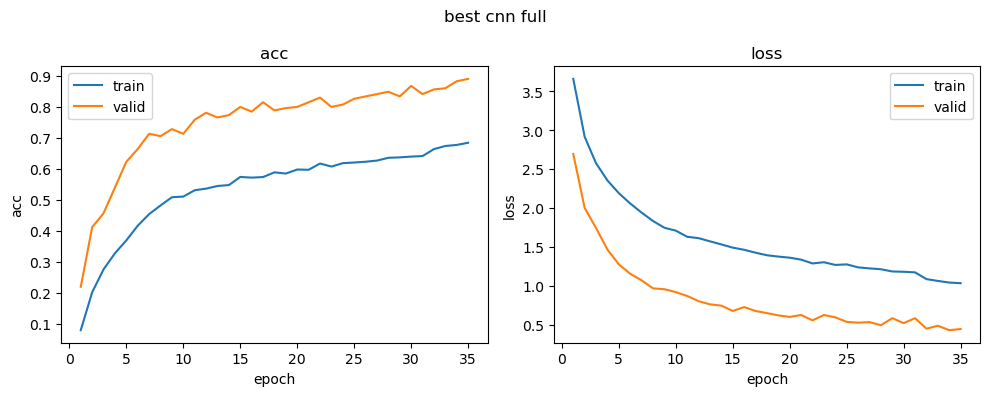

In [14]:
clear_memory()

full_train_gen, full_valid_gen, _ = make_generators(
    train_df,
    valid_df,
    None,
    batch_size=FINAL_BATCH_SIZE,
    preprocess_fn=None,
    augment=True,
)

best_cnn_model = CNN_BUILDERS[best_cnn_cfg["builder"]](NUM_CLASSES, dropout=float(best_cnn_cfg["dropout"]))
best_cnn_loss = keras.losses.CategoricalCrossentropy(label_smoothing=float(best_cnn_cfg["label_smoothing"]))
best_cnn_model.compile(
    optimizer=Adam(learning_rate=float(best_cnn_cfg["lr"])),
    loss=best_cnn_loss,
    metrics=["accuracy"],
)

best_cnn_history = best_cnn_model.fit(
    full_train_gen,
    validation_data=full_valid_gen,
    epochs=FINAL_EPOCHS,
    callbacks=make_callbacks("best_cnn_full", patience=FINAL_PATIENCE),
    verbose=1,
)

plot_history(best_cnn_history, "best cnn full", "best_cnn_full")
best_cnn_model.save(CHECKPOINTS_DIR / "best_cnn_full_last.keras")

## 15. Transfer learning

Modele sa trenowane pojedynczo.
Kazdy model ma wlasny preprocessing wejscia.
Nie trzymamy wszystkich modeli jednoczesnie w pamieci.

In [15]:
def get_preprocess_and_base(model_name):
    if model_name == "VGG16":
        from tensorflow.keras.applications.vgg16 import preprocess_input
        return preprocess_input, VGG16
    if model_name == "ResNet50":
        from tensorflow.keras.applications.resnet50 import preprocess_input
        return preprocess_input, ResNet50
    if model_name == "MobileNetV2":
        from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
        return preprocess_input, MobileNetV2
    if model_name == "EfficientNetB0":
        from tensorflow.keras.applications.efficientnet import preprocess_input
        return preprocess_input, EfficientNetB0
    raise ValueError(model_name)

def build_transfer_model(model_name, num_classes, dense_units=256, dropout=0.30, trainable_layers=20):
    preprocess_fn, base_class = get_preprocess_and_base(model_name)
    base_model = base_class(
        weights="imagenet",
        include_top=False,
        input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS),
    )
    base_model.trainable = True

    if trainable_layers <= 0:
        for layer in base_model.layers:
            layer.trainable = False
    else:
        for layer in base_model.layers[:-trainable_layers]:
            layer.trainable = False
        for layer in base_model.layers[-trainable_layers:]:
            layer.trainable = True

    inputs = layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
    x = preprocess_fn(inputs)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(dense_units, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = Model(inputs, outputs, name=f"tl_{model_name}")
    return model, preprocess_fn

transfer_configs = [
    {"name": "VGG16", "trainable_layers": 4, "lr": 3e-4, "dropout": 0.30, "dense_units": 256},
    {"name": "ResNet50", "trainable_layers": 10, "lr": 1e-4, "dropout": 0.30, "dense_units": 256},
    {"name": "MobileNetV2", "trainable_layers": 20, "lr": 3e-4, "dropout": 0.25, "dense_units": 192},
    {"name": "EfficientNetB0", "trainable_layers": 20, "lr": 1e-4, "dropout": 0.25, "dense_units": 192},
]

pd.DataFrame(transfer_configs)

,name,trainable_layers,lr,dropout,dense_units
0,VGG16,4,0.0003,0.30,256
1,ResNet50,10,0.0001,0.30,256
2,MobileNetV2,20,0.0003,0.25,192
3,EfficientNetB0,20,0.0001,0.25,192


## 16. Trening modeli transfer learning

Start: VGG16
Found 7624 validated image filenames belonging to 53 classes.
Found 265 validated image filenames belonging to 53 classes.
Epoch 1/18


I0000 00:00:1775293421.453595     709 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_121076__.72
W0000 00:00:1775293424.772209     709 bfc_allocator.cc:383] Garbage collection: deallocate free memory regions (i.e., allocations) so that we can re-allocate a larger region to avoid OOM due to memory fragmentation. If you see this message frequently, you are running near the threshold of the available device memory and re-allocation may incur great performance overhead. You may try smaller batch sizes to observe the performance impact. Set TF_ENABLE_GPU_GARBAGE_COLLECTION=false if you'd like to disable this feature.


303/477 ━━━━━━━━━━━━━━━━━━━━ 27s 160ms/step - accuracy: 0.0171 - loss: 4.1522

I0000 00:00:1775293483.361280     710 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_121076__.72


477/477 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.0174 - loss: 4.0947
Epoch 1: val_accuracy improved from None to 0.01887, saving model to /home/chemik/studia/ggsn/agh_ggsn/ex2/results/checkpoints/tl_VGG16.keras
477/477 ━━━━━━━━━━━━━━━━━━━━ 115s 206ms/step - accuracy: 0.0177 - loss: 3.9897 - val_accuracy: 0.0189 - val_loss: 3.9705 - learning_rate: 3.0000e-04
Epoch 2/18
477/477 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.0248 - loss: 3.9676
Epoch 2: val_accuracy did not improve from 0.01887
477/477 ━━━━━━━━━━━━━━━━━━━━ 77s 161ms/step - accuracy: 0.0220 - loss: 3.9679 - val_accuracy: 0.0189 - val_loss: 3.9710 - learning_rate: 3.0000e-04
Epoch 3/18
477/477 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.0223 - loss: 3.9665
Epoch 3: val_accuracy did not improve from 0.01887

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
477/477 ━━━━━━━━━━━━━━━━━━━━ 87s 182ms/step - accuracy: 0.0230 - loss: 3.9665 - val_accuracy: 0.0189 - val_loss: 3.9719 - learnin

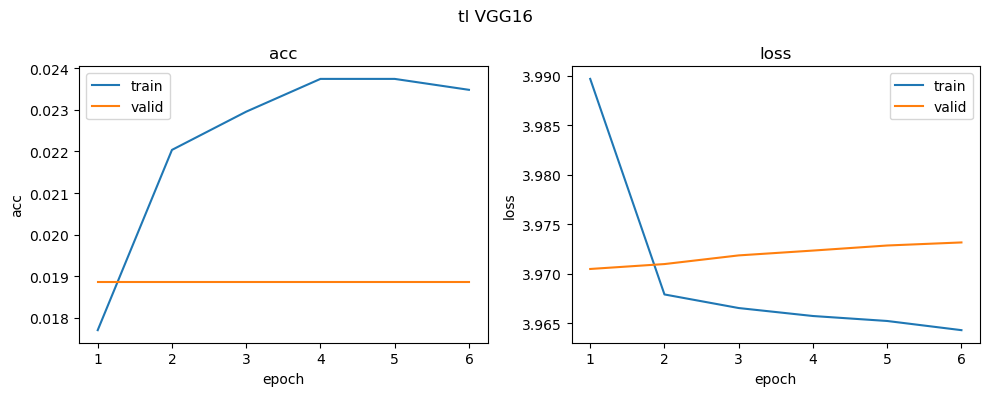

Start: ResNet50
Found 7624 validated image filenames belonging to 53 classes.
Found 265 validated image filenames belonging to 53 classes.
Epoch 1/18


I0000 00:00:1775293937.047047     710 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_146925__.199


117/477 ━━━━━━━━━━━━━━━━━━━━ 56s 158ms/step - accuracy: 0.0348 - loss: 4.5403

I0000 00:00:1775293972.895210     710 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_146925__.199


477/477 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.0961 - loss: 3.8494
Epoch 1: val_accuracy improved from None to 0.40755, saving model to /home/chemik/studia/ggsn/agh_ggsn/ex2/results/checkpoints/tl_ResNet50.keras
477/477 ━━━━━━━━━━━━━━━━━━━━ 132s 225ms/step - accuracy: 0.1624 - loss: 3.2836 - val_accuracy: 0.4075 - val_loss: 2.0687 - learning_rate: 1.0000e-04
Epoch 2/18
477/477 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.3289 - loss: 2.3364
Epoch 2: val_accuracy improved from 0.40755 to 0.46038, saving model to /home/chemik/studia/ggsn/agh_ggsn/ex2/results/checkpoints/tl_ResNet50.keras
477/477 ━━━━━━━━━━━━━━━━━━━━ 85s 177ms/step - accuracy: 0.3527 - loss: 2.2540 - val_accuracy: 0.4604 - val_loss: 1.7049 - learning_rate: 1.0000e-04
Epoch 3/18
477/477 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.4447 - loss: 1.8944
Epoch 3: val_accuracy improved from 0.46038 to 0.52075, saving model to /home/chemik/studia/ggsn/agh_ggsn/ex2/results/checkpoints/tl_ResNet50.keras
477/477 ━

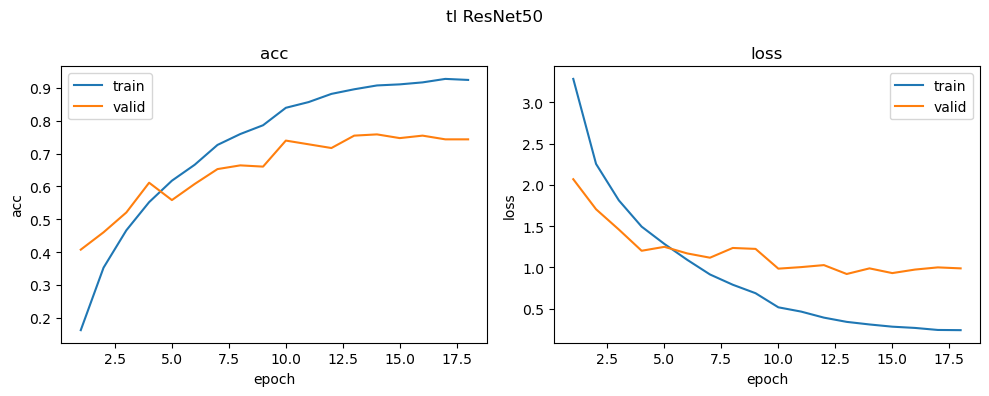

Start: MobileNetV2
Found 7624 validated image filenames belonging to 53 classes.
Found 265 validated image filenames belonging to 53 classes.
Epoch 1/18


I0000 00:00:1775295455.500393     712 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_210705__.152
E0000 00:00:1775295465.217339     712 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


442/477 ━━━━━━━━━━━━━━━━━━━━ 5s 167ms/step - accuracy: 0.1638 - loss: 3.2626

I0000 00:00:1775295564.388697     711 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_210705__.152
E0000 00:00:1775295582.902356     711 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


477/477 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.1717 - loss: 3.2209

E0000 00:00:1775295619.918553     711 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_accuracy improved from None to 0.41509, saving model to /home/chemik/studia/ggsn/agh_ggsn/ex2/results/checkpoints/tl_MobileNetV2.keras
477/477 ━━━━━━━━━━━━━━━━━━━━ 182s 296ms/step - accuracy: 0.2743 - loss: 2.6772 - val_accuracy: 0.4151 - val_loss: 2.2084 - learning_rate: 3.0000e-04
Epoch 2/18
477/477 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.4981 - loss: 1.7411
Epoch 2: val_accuracy improved from 0.41509 to 0.57736, saving model to /home/chemik/studia/ggsn/agh_ggsn/ex2/results/checkpoints/tl_MobileNetV2.keras
477/477 ━━━━━━━━━━━━━━━━━━━━ 93s 195ms/step - accuracy: 0.5185 - loss: 1.6476 - val_accuracy: 0.5774 - val_loss: 1.6258 - learning_rate: 3.0000e-04
Epoch 3/18
477/477 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.6313 - loss: 1.2489
Epoch 3: val_accuracy did not improve from 0.57736
477/477 ━━━━━━━━━━━━━━━━━━━━ 76s 159ms/step - accuracy: 0.6342 - loss: 1.2447 - val_accuracy: 0.5208 - val_loss: 2.0483 - learning_rate: 3.0000e-04
Epoch 4/18
477/477 ━━━━━━━━━

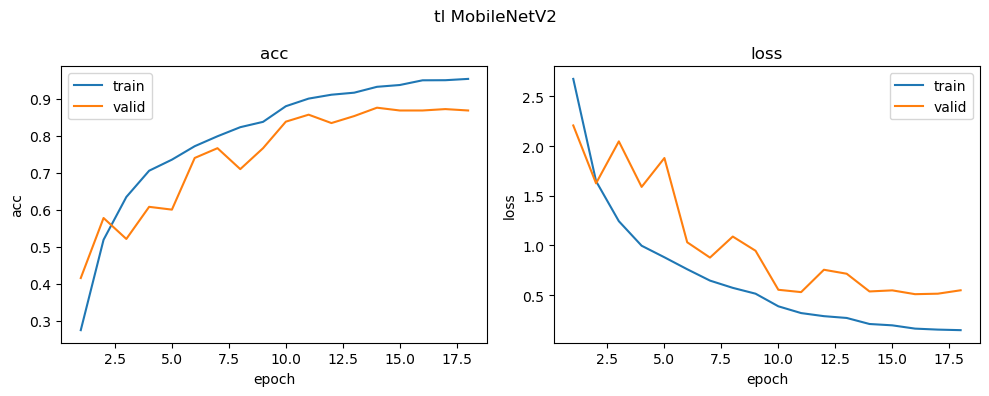

Start: EfficientNetB0
Found 7624 validated image filenames belonging to 53 classes.
Found 265 validated image filenames belonging to 53 classes.
Epoch 1/18


I0000 00:00:1775297014.608241     710 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_278618__.276
E0000 00:00:1775297016.090756     710 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1775297021.501024     710 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1775297024.847274     710 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


325/477 ━━━━━━━━━━━━━━━━━━━━ 25s 165ms/step - accuracy: 0.0472 - loss: 3.8801

I0000 00:00:1775297107.002109     709 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_278618__.276
E0000 00:00:1775297111.835538     709 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1775297113.047132     709 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1775297114.159009     709 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


477/477 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.0644 - loss: 3.7777

E0000 00:00:1775297174.662264     710 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1775297178.935960     710 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1775297181.288165     710 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_accuracy improved from None to 0.32830, saving model to /home/chemik/studia/ggsn/agh_ggsn/ex2/results/checkpoints/tl_EfficientNetB0.keras
477/477 ━━━━━━━━━━━━━━━━━━━━ 195s 297ms/step - accuracy: 0.1167 - loss: 3.4580 - val_accuracy: 0.3283 - val_loss: 2.3639 - learning_rate: 1.0000e-04
Epoch 2/18
477/477 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.2728 - loss: 2.6240
Epoch 2: val_accuracy improved from 0.32830 to 0.44151, saving model to /home/chemik/studia/ggsn/agh_ggsn/ex2/results/checkpoints/tl_EfficientNetB0.keras
477/477 ━━━━━━━━━━━━━━━━━━━━ 78s 163ms/step - accuracy: 0.2991 - loss: 2.4613 - val_accuracy: 0.4415 - val_loss: 1.7363 - learning_rate: 1.0000e-04
Epoch 3/18
477/477 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.3910 - loss: 2.0885
Epoch 3: val_accuracy improved from 0.44151 to 0.53962, saving model to /home/chemik/studia/ggsn/agh_ggsn/ex2/results/checkpoints/tl_EfficientNetB0.keras
477/477 ━━━━━━━━━━━━━━━━━━━━ 78s 163ms/step - accuracy: 0.4081 - lo

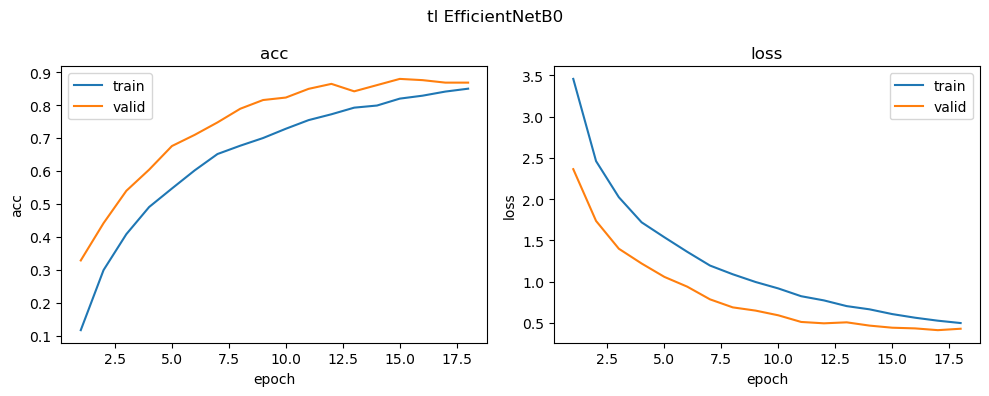

,name,best_val_acc,best_epoch,model_path
0,EfficientNetB0,0.879245,15,/home/chemik/studia/ggsn/agh_ggsn/ex2/results/...
1,MobileNetV2,0.875472,14,/home/chemik/studia/ggsn/agh_ggsn/ex2/results/...
2,ResNet50,0.758491,14,/home/chemik/studia/ggsn/agh_ggsn/ex2/results/...
3,VGG16,0.018868,1,/home/chemik/studia/ggsn/agh_ggsn/ex2/results/...


In [16]:
transfer_results = []

for cfg in transfer_configs:
    clear_memory()
    print("=" * 70)
    print("Start:", cfg["name"])
    print("=" * 70)

    train_gen, valid_gen, _ = make_generators(
        train_df,
        valid_df,
        None,
        batch_size=TRANSFER_BATCH_SIZE,
        preprocess_fn=None,
        augment=True,
        raw_input=True,
    )

    model, _ = build_transfer_model(
        cfg["name"],
        NUM_CLASSES,
        dense_units=cfg["dense_units"],
        dropout=cfg["dropout"],
        trainable_layers=cfg["trainable_layers"],
    )

    model.compile(
        optimizer=Adam(learning_rate=cfg["lr"]),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

    history = model.fit(
        train_gen,
        validation_data=valid_gen,
        epochs=TRANSFER_EPOCHS,
        callbacks=make_callbacks(f"tl_{cfg['name']}", patience=TRANSFER_PATIENCE),
        verbose=1,
    )

    plot_history(history, f"tl {cfg['name']}", f"tl_{cfg['name']}")

    transfer_results.append({
        "name": cfg["name"],
        "best_val_acc": float(np.max(history.history["val_accuracy"])),
        "best_epoch": int(np.argmax(history.history["val_accuracy"]) + 1),
        "model_path": str(CHECKPOINTS_DIR / f"tl_{cfg['name']}.keras"),
    })

    del model, history, train_gen, valid_gen
    gc.collect()

transfer_df = pd.DataFrame(transfer_results).sort_values("best_val_acc", ascending=False).reset_index(drop=True)
transfer_df.to_csv(RESULTS_DIR / "transfer_summary.csv", index=False)
transfer_df

## 17. Zbiorcze porownanie

In [17]:
all_model_rows = []

all_model_rows.append({
    "group": "cnn",
    "name": "best_cnn_full",
    "best_val_acc": float(np.max(best_cnn_history.history["val_accuracy"])),
    "model_path": str(CHECKPOINTS_DIR / "best_cnn_full.keras"),
})

for _, row in transfer_df.iterrows():
    all_model_rows.append({
        "group": "transfer",
        "name": row["name"],
        "best_val_acc": float(row["best_val_acc"]),
        "model_path": row["model_path"],
    })

all_models_df = pd.DataFrame(all_model_rows).sort_values("best_val_acc", ascending=False).reset_index(drop=True)
all_models_df.to_csv(RESULTS_DIR / "all_models_summary.csv", index=False)
all_models_df

,group,name,best_val_acc,model_path
0,cnn,best_cnn_full,0.890566,/home/chemik/studia/ggsn/agh_ggsn/ex2/results/...
1,transfer,EfficientNetB0,0.879245,/home/chemik/studia/ggsn/agh_ggsn/ex2/results/...
2,transfer,MobileNetV2,0.875472,/home/chemik/studia/ggsn/agh_ggsn/ex2/results/...
3,transfer,ResNet50,0.758491,/home/chemik/studia/ggsn/agh_ggsn/ex2/results/...
4,transfer,VGG16,0.018868,/home/chemik/studia/ggsn/agh_ggsn/ex2/results/...


## 18. Ewaluacja na test

In [18]:
test_results = []

# final cnn
clear_memory()
_, _, cnn_test_gen = make_generators(
    train_df.iloc[:1],
    valid_df.iloc[:1] if not valid_df.empty else valid_df,
    test_df,
    batch_size=FINAL_BATCH_SIZE,
    preprocess_fn=None,
    augment=False,
)
cnn_model = load_saved_model(CHECKPOINTS_DIR / "best_cnn_full.keras")
test_results.append(evaluate_model(cnn_model, cnn_test_gen, "best_cnn_full"))
del cnn_model, cnn_test_gen
gc.collect()

# transfer models
for _, row in transfer_df.iterrows():
    clear_memory()
    _, _, test_gen = make_generators(
        train_df.iloc[:1],
        valid_df.iloc[:1] if not valid_df.empty else valid_df,
        test_df,
        batch_size=TRANSFER_BATCH_SIZE,
        preprocess_fn=None,
        augment=False,
        raw_input=True,
    )
    model = load_saved_model(row["model_path"])
    test_results.append(evaluate_model(model, test_gen, row["name"]))
    del model, test_gen
    gc.collect()

test_df_results = pd.DataFrame(test_results).sort_values("accuracy", ascending=False).reset_index(drop=True)
test_df_results.to_csv(RESULTS_DIR / "test_results.csv", index=False)
test_df_results

Found 1 validated image filenames belonging to 1 classes.
Found 1 validated image filenames belonging to 1 classes.
Found 265 validated image filenames belonging to 53 classes.
best_cnn_full: acc=0.8717, loss=0.5085
Found 1 validated image filenames belonging to 1 classes.
Found 1 validated image filenames belonging to 1 classes.
Found 265 validated image filenames belonging to 53 classes.
EfficientNetB0: acc=0.8075, loss=0.7095
Found 1 validated image filenames belonging to 1 classes.
Found 1 validated image filenames belonging to 1 classes.
Found 265 validated image filenames belonging to 53 classes.
MobileNetV2: acc=0.8528, loss=0.6179
Found 1 validated image filenames belonging to 1 classes.
Found 1 validated image filenames belonging to 1 classes.
Found 265 validated image filenames belonging to 53 classes.
ResNet50: acc=0.7057, loss=1.2242
Found 1 validated image filenames belonging to 1 classes.
Found 1 validated image filenames belonging to 1 classes.
Found 265 validated image 

,model,accuracy,loss
0,best_cnn_full,0.871698,0.508522
1,MobileNetV2,0.852830,0.617874
2,EfficientNetB0,0.807547,0.709530
3,ResNet50,0.705660,1.224225
4,VGG16,0.018868,3.970486


## 19. Wykres test

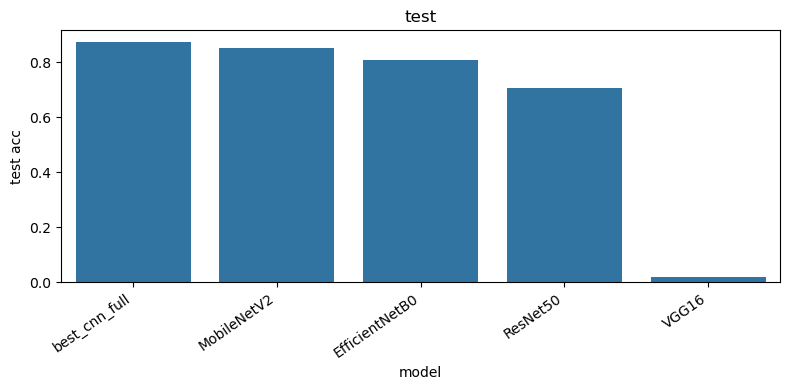

best overall: best_cnn_full


In [19]:
plt.figure(figsize=(8, 4))
sns.barplot(data=test_df_results, x="model", y="accuracy")
plt.xticks(rotation=35, ha="right")
plt.xlabel("model")
plt.ylabel("test acc")
plt.title("test")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "test_results.png", dpi=140, bbox_inches="tight")
plt.show()

best_overall_name = test_df_results.iloc[0]["model"]
print("best overall:", best_overall_name)

## 19a. Zbiorcze wykresy modeli

Porownujemy wyniki walidacyjne, testowe i przebieg uczenia.
Historie sa wczytywane z plikow CSV, wiec nie trzeba trzymac wszystkiego w RAM.

,group,model,val_acc,test_acc
6,cnn_final,best_cnn_full,0.890566,0.871698
0,cnn_search,cnn_small_lr1e3,0.559748,NaN
1,cnn_search,cnn_small_lr3e4,0.459119,NaN
2,cnn_search,cnn_residual_lr3e4,0.132075,NaN
3,cnn_search,cnn_bn_gap_lr1e3,0.125786,NaN
4,cnn_search,cnn_bn_gap_lr3e4,0.119497,NaN
5,cnn_search,cnn_separable_lr1e3,0.018868,NaN
7,transfer,EfficientNetB0,0.879245,0.807547
8,transfer,MobileNetV2,0.875472,0.852830
9,transfer,ResNet50,0.758491,0.705660


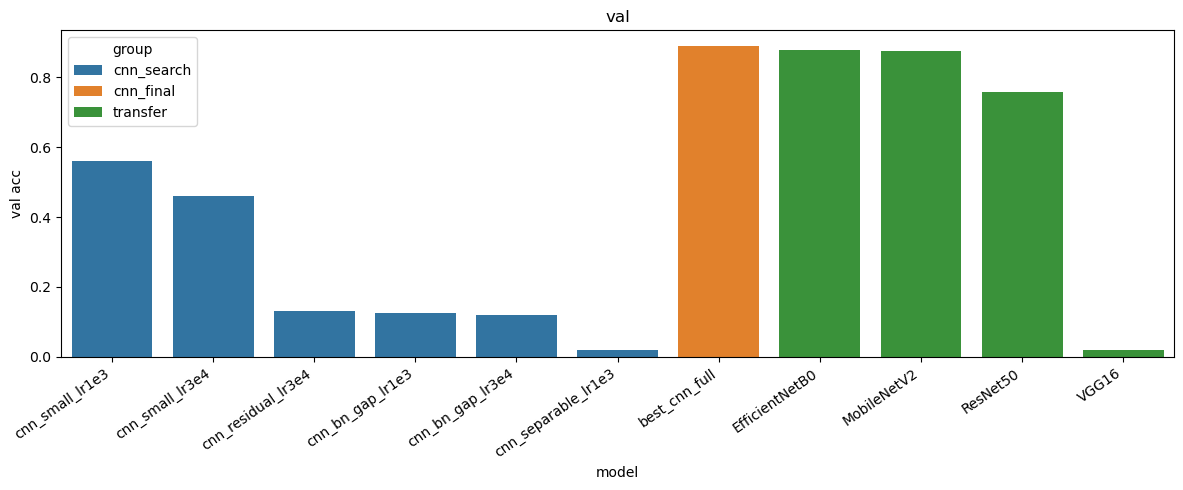

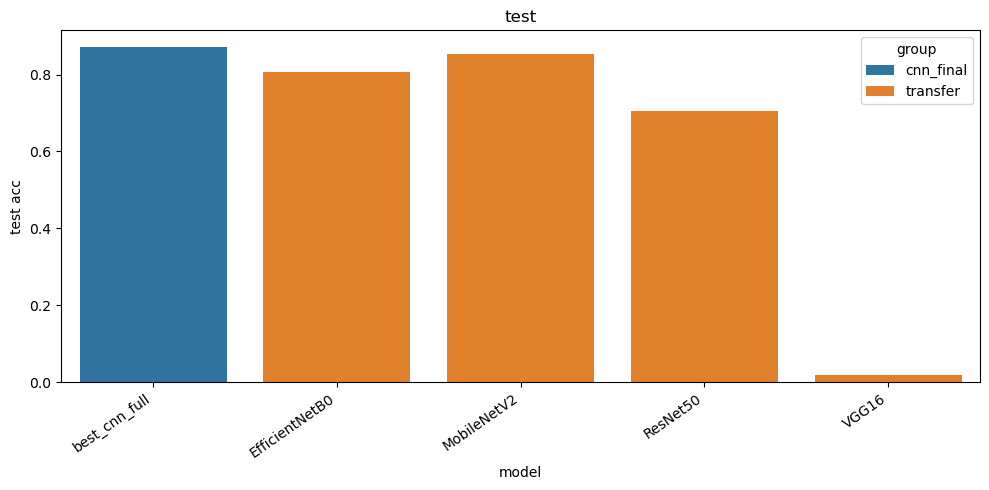

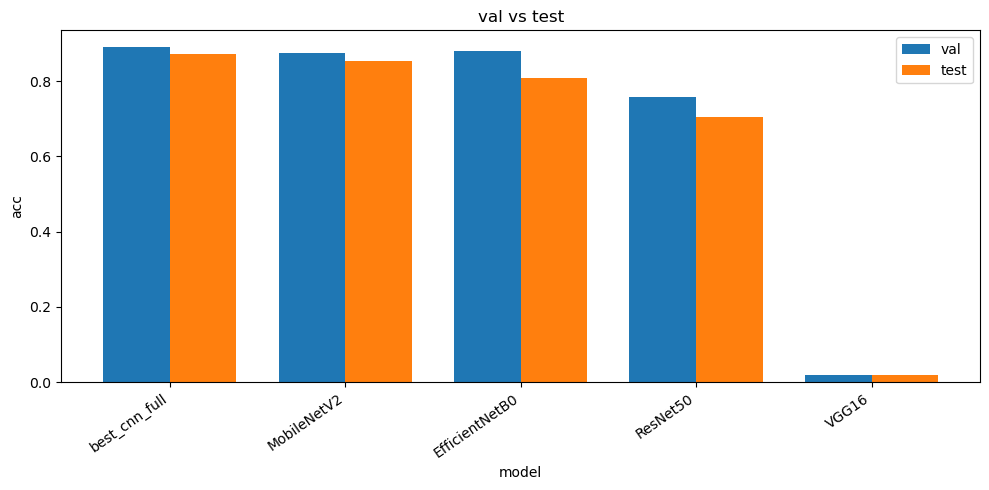

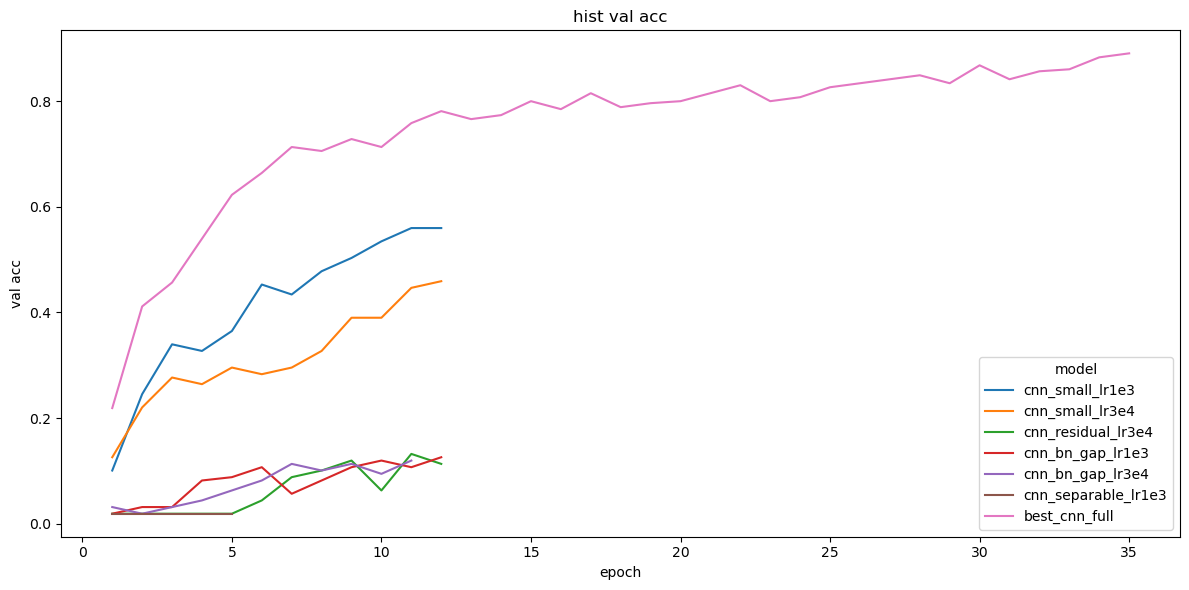

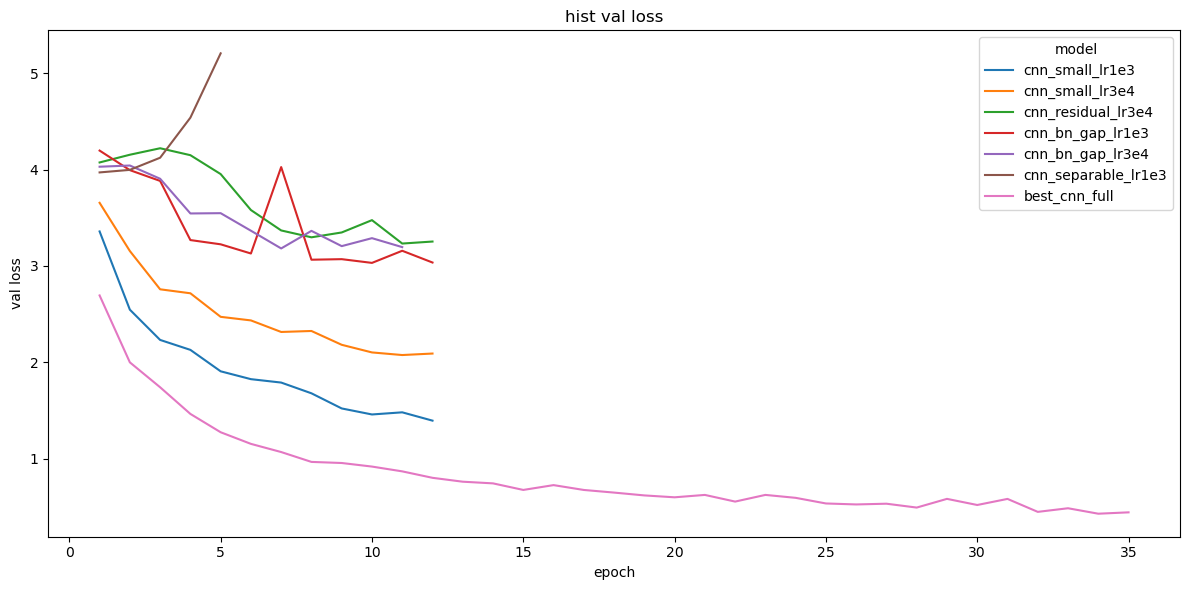

In [37]:
def load_history_if_exists(name):
    path = HISTORY_DIR / f"{name}.csv"
    if path.exists():
        df = pd.read_csv(path)
        df["model"] = name
        return df
    return None


summary_rows = []

for _, row in cnn_search_df.iterrows():
    summary_rows.append({
        "group": "cnn_search",
        "model": row["name"],
        "val_acc": float(row["best_val_acc"]),
        "test_acc": np.nan,
    })

summary_rows.append({
    "group": "cnn_final",
    "model": "best_cnn_full",
    "val_acc": float(np.max(best_cnn_history.history["val_accuracy"])),
    "test_acc": float(test_df_results.loc[test_df_results["model"] == "best_cnn_full", "accuracy"].iloc[0]),
})

for _, row in transfer_df.iterrows():
    model_name = row["name"]
    test_match = test_df_results.loc[test_df_results["model"] == model_name, "accuracy"]
    summary_rows.append({
        "group": "transfer",
        "model": model_name,
        "val_acc": float(row["best_val_acc"]),
        "test_acc": float(test_match.iloc[0]) if len(test_match) else np.nan,
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df.sort_values(["group", "val_acc"], ascending=[True, False]))

plt.figure(figsize=(12, 5))
plot_df = summary_df.dropna(subset=["val_acc"]).copy()
sns.barplot(data=plot_df, x="model", y="val_acc", hue="group")
plt.xticks(rotation=35, ha="right")
plt.xlabel("model")
plt.ylabel("val acc")
plt.title("val")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "all_models_val.png", dpi=140, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 5))
plot_df = summary_df.dropna(subset=["test_acc"]).copy()
sns.barplot(data=plot_df, x="model", y="test_acc", hue="group")
plt.xticks(rotation=35, ha="right")
plt.xlabel("model")
plt.ylabel("test acc")
plt.title("test")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "all_models_test.png", dpi=140, bbox_inches="tight")
plt.show()

compare_df = summary_df.dropna(subset=["test_acc"]).copy()
compare_df = compare_df.sort_values("test_acc", ascending=False)

plt.figure(figsize=(10, 5))
x = np.arange(len(compare_df))
width = 0.38

plt.bar(x - width / 2, compare_df["val_acc"], width=width, label="val")
plt.bar(x + width / 2, compare_df["test_acc"], width=width, label="test")
plt.xticks(x, compare_df["model"], rotation=35, ha="right")
plt.xlabel("model")
plt.ylabel("acc")
plt.title("val vs test")
plt.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "all_models_val_vs_test.png", dpi=140, bbox_inches="tight")
plt.show()

history_names = [row["name"] for _, row in cnn_search_df.iterrows()]
history_names += ["best_cnn_full"]
history_names += [row["name"] for _, row in transfer_df.iterrows()]

history_frames = []
for name in history_names:
    hist_df = load_history_if_exists(name)
    if hist_df is not None:
        history_frames.append(hist_df)

if history_frames:
    all_hist_df = pd.concat(history_frames, ignore_index=True)

    plt.figure(figsize=(12, 6))
    sns.lineplot(data=all_hist_df, x="epoch", y="val_accuracy", hue="model")
    plt.xlabel("epoch")
    plt.ylabel("val acc")
    plt.title("hist val acc")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "all_histories_val_acc.png", dpi=140, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(12, 6))
    sns.lineplot(data=all_hist_df, x="epoch", y="val_loss", hue="model")
    plt.xlabel("epoch")
    plt.ylabel("val loss")
    plt.title("hist val loss")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "all_histories_val_loss.png", dpi=140, bbox_inches="tight")
    plt.show()
else:
    print("Brak plikow historii w HISTORY_DIR")

## 20. Najlepszy model do dalszej analizy

In [40]:
def resolve_model_for_analysis(model_name):
    if model_name == "best_cnn_full":
        model = load_saved_model(CHECKPOINTS_DIR / "best_cnn_full.keras")
        preprocess_fn = None
        return model, preprocess_fn

    model = load_saved_model(CHECKPOINTS_DIR / f"tl_{model_name}.keras")
    preprocess_fn = None
    return model, preprocess_fn

analysis_model, analysis_preprocess = resolve_model_for_analysis(best_overall_name)
print("loaded:", best_overall_name)

loaded: best_cnn_full


## 21. Confusion matrix

Found 1 validated image filenames belonging to 1 classes.
Found 1 validated image filenames belonging to 1 classes.
Found 265 validated image filenames belonging to 53 classes.


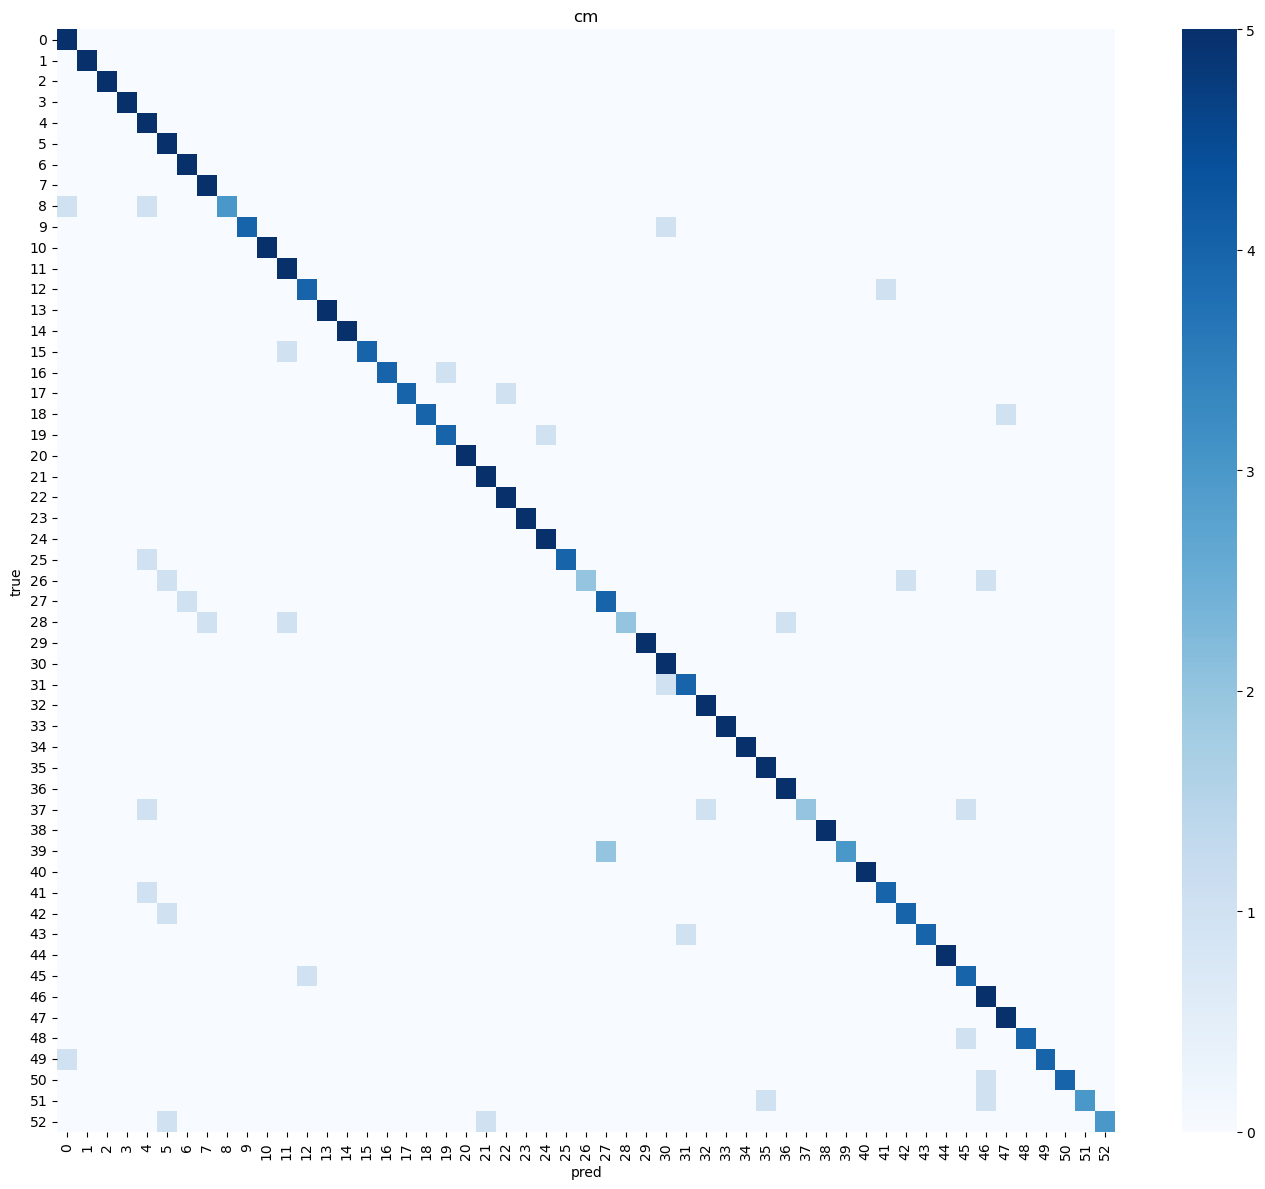

                   precision    recall  f1-score   support

     ace of clubs       0.71      1.00      0.83         5
  ace of diamonds       1.00      1.00      1.00         5
    ace of hearts       1.00      1.00      1.00         5
    ace of spades       1.00      1.00      1.00         5
   eight of clubs       0.56      1.00      0.71         5
eight of diamonds       0.62      1.00      0.77         5
  eight of hearts       0.83      1.00      0.91         5
  eight of spades       0.83      1.00      0.91         5
    five of clubs       1.00      0.60      0.75         5
 five of diamonds       1.00      0.80      0.89         5
   five of hearts       1.00      1.00      1.00         5
   five of spades       0.71      1.00      0.83         5
    four of clubs       0.80      0.80      0.80         5
 four of diamonds       1.00      1.00      1.00         5
   four of hearts       1.00      1.00      1.00         5
   four of spades       1.00      0.80      0.89       

In [41]:
_, _, analysis_test_gen = make_generators(
    train_df.iloc[:1],
    valid_df.iloc[:1] if not valid_df.empty else valid_df,
    test_df,
    batch_size=FINAL_BATCH_SIZE if best_overall_name == "best_cnn_full" else TRANSFER_BATCH_SIZE,
    preprocess_fn=analysis_preprocess,
    augment=False,
    raw_input=(best_overall_name != "best_cnn_full"),
)

predictions = analysis_model.predict(analysis_test_gen, verbose=0)
y_pred = np.argmax(predictions, axis=1)
y_true = analysis_test_gen.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, cmap="Blues", cbar=True)
plt.xlabel("pred")
plt.ylabel("true")
plt.title("cm")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "confusion_matrix_best.png", dpi=140, bbox_inches="tight")
plt.show()

print(classification_report(y_true, y_pred, target_names=list(analysis_test_gen.class_indices.keys()), zero_division=0))

## 22. Filtry CNN

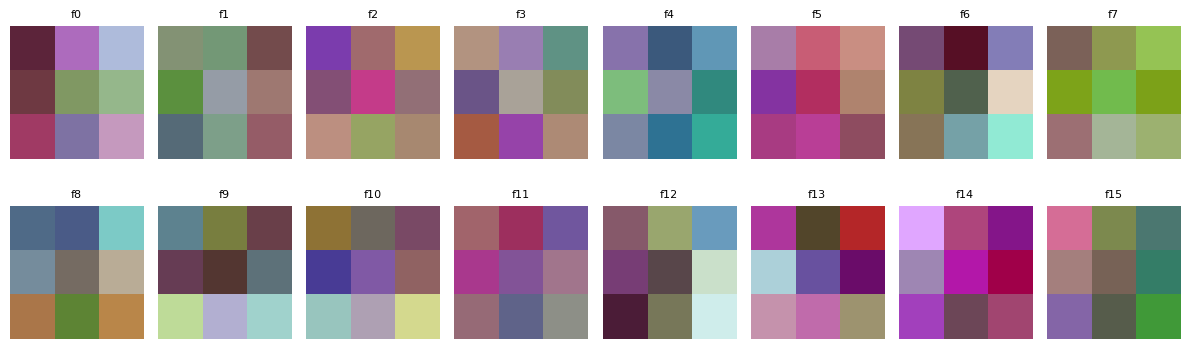

In [42]:
def visualize_filters(model, save_name, n_filters=16):
    conv_layers = [layer for layer in model.layers if isinstance(layer, layers.Conv2D)]
    if not conv_layers:
        print("Brak prostych warstw Conv2D w tym modelu")
        return

    kernel = conv_layers[0].get_weights()[0]
    kernel = (kernel - kernel.min()) / (kernel.max() - kernel.min() + 1e-8)

    n_filters = min(n_filters, kernel.shape[-1])
    fig, axes = plt.subplots(2, int(np.ceil(n_filters / 2)), figsize=(12, 4))
    axes = np.array(axes).ravel()

    for i in range(n_filters):
        filt = kernel[:, :, :, i]
        if filt.shape[-1] == 3:
            axes[i].imshow(filt)
        else:
            axes[i].imshow(filt[:, :, 0], cmap="gray")
        axes[i].axis("off")
        axes[i].set_title(f"f{i}", fontsize=8)

    for i in range(n_filters, len(axes)):
        axes[i].axis("off")

    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"{save_name}_filters.png", dpi=140, bbox_inches="tight")
    plt.show()

if best_overall_name == "best_cnn_full":
    visualize_filters(analysis_model, "best_cnn", n_filters=16)
else:
    print("Filtry zostawiamy tylko dla CNN od zera")

## 23. Aktywacje

Wybrane pliki:
/home/chemik/studia/ggsn/agh_ggsn/ex2/../data/cards-image-datasetclassification/test/seven of hearts/4.jpg
/home/chemik/studia/ggsn/agh_ggsn/ex2/../data/cards-image-datasetclassification/test/king of hearts/3.jpg
/home/chemik/studia/ggsn/agh_ggsn/ex2/../data/cards-image-datasetclassification/test/jack of spades/2.jpg
/home/chemik/studia/ggsn/agh_ggsn/ex2/../data/cards-image-datasetclassification/test/eight of clubs/4.jpg
/home/chemik/studia/ggsn/agh_ggsn/ex2/../data/cards-image-datasetclassification/test/ace of diamonds/4.jpg


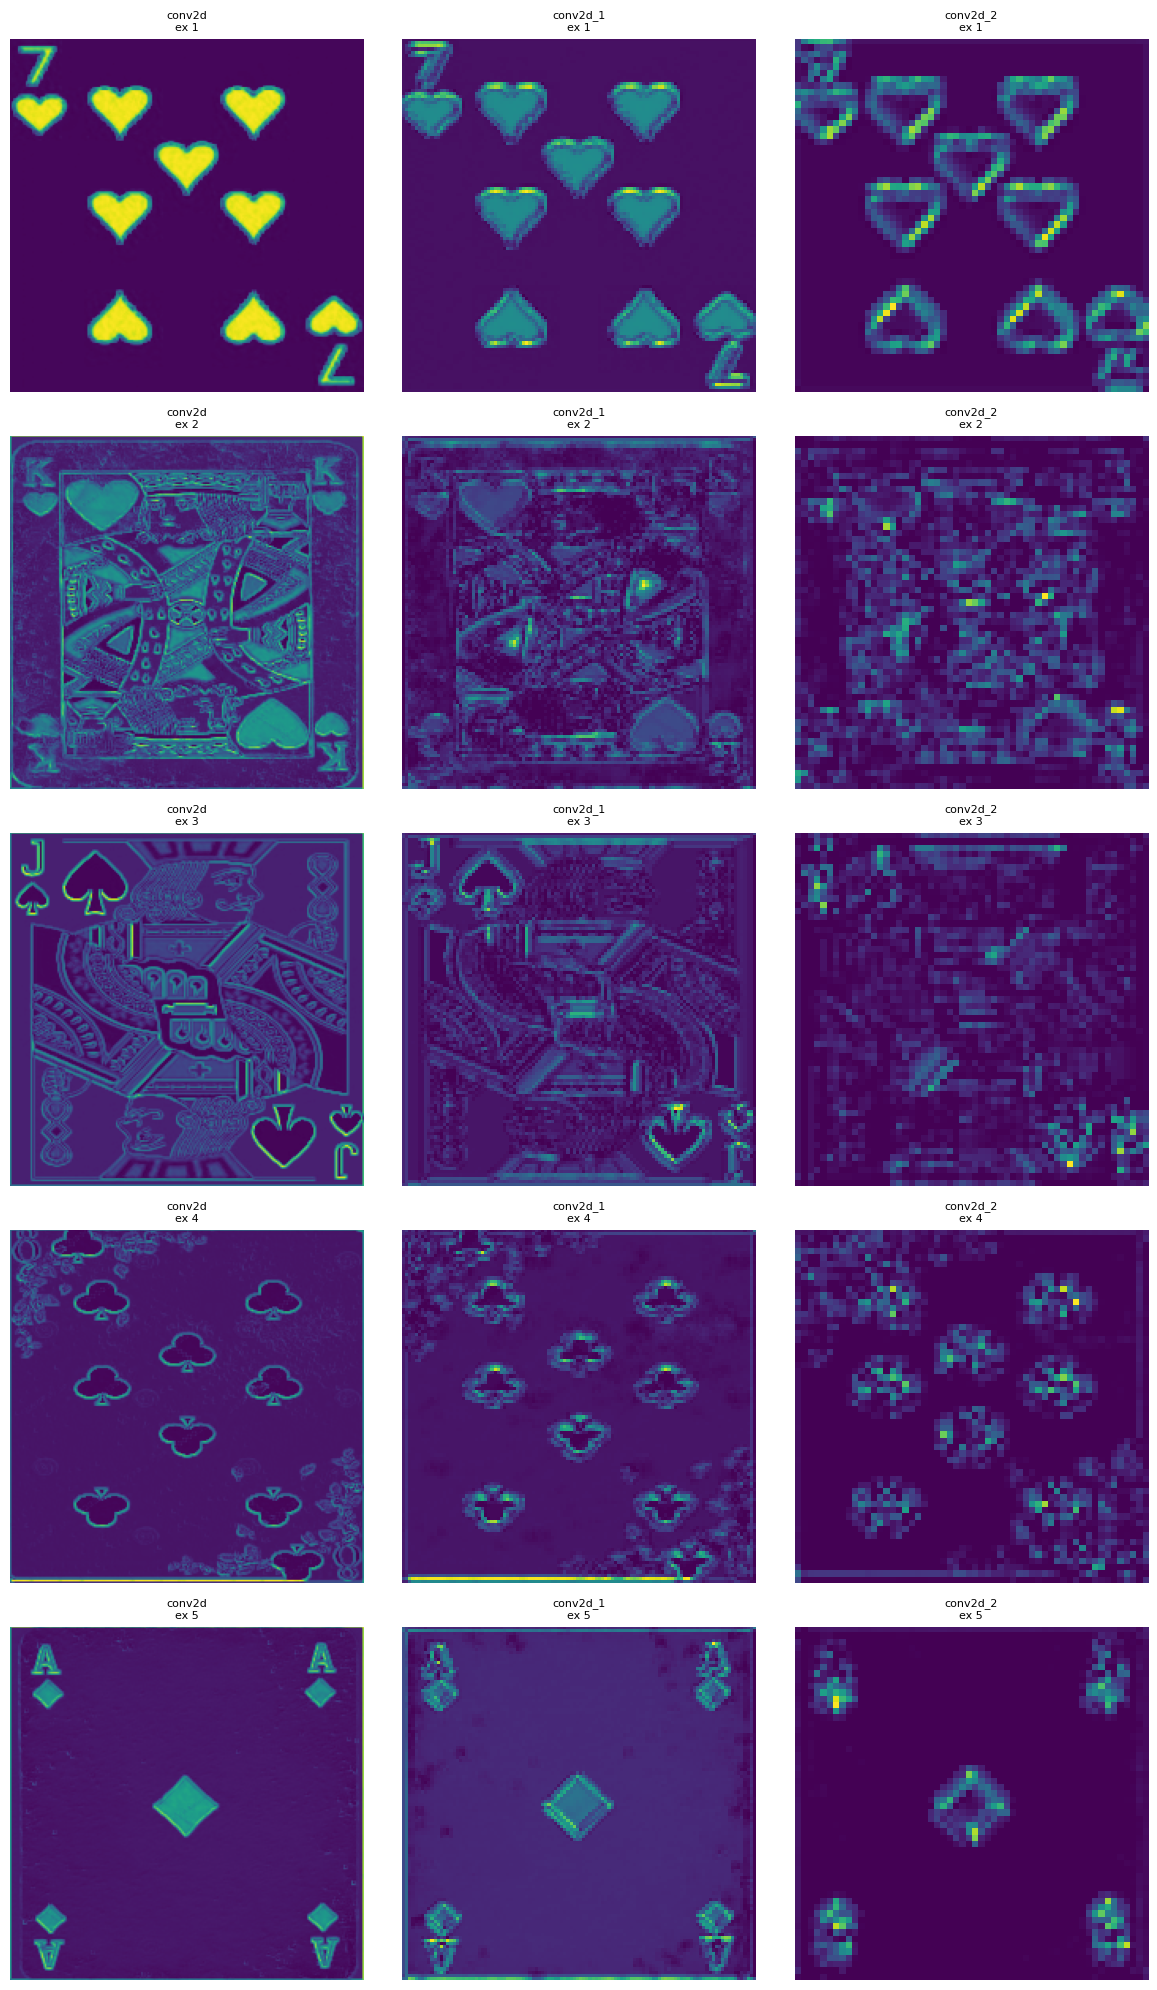

In [48]:
def preprocess_single_image(img_path, preprocess_fn=None):
    img = load_img(img_path, target_size=IMG_SIZE)
    arr = img_to_array(img)
    arr = np.expand_dims(arr, axis=0)
    if preprocess_fn is None:
        arr = arr / 255.0
    else:
        arr = preprocess_fn(arr.copy())
    return img, arr

def get_first_conv_names(model, max_layers=6):
    names = []
    for layer in model.layers:
        if isinstance(layer, keras.Model):
            for sub in layer.layers:
                if isinstance(sub, (layers.Conv2D, layers.SeparableConv2D, layers.DepthwiseConv2D)):
                    names.append(sub.name)
        elif isinstance(layer, (layers.Conv2D, layers.SeparableConv2D, layers.DepthwiseConv2D)):
            names.append(layer.name)
    return names[:max_layers]

def find_nested_layer(model, layer_name):
    for layer in model.layers:
        if layer.name == layer_name:
            return layer
        if isinstance(layer, keras.Model):
            try:
                return layer.get_layer(layer_name)
            except Exception:
                pass
    raise ValueError(layer_name)

NUM_EXAMPLES = 5

sample_analysis_paths = test_df.sample(NUM_EXAMPLES, random_state=SEED)["filepath"].tolist()
print("Wybrane pliki:")
for p in sample_analysis_paths:
    print(p)

conv_names = get_first_conv_names(analysis_model, max_layers=4)

if not conv_names:
    print("Brak warstw konwolucyjnych")
else:
    outputs = [find_nested_layer(analysis_model, name).output for name in conv_names]
    activation_model = Model(inputs=analysis_model.inputs, outputs=outputs)

    fig, axes = plt.subplots(NUM_EXAMPLES, len(conv_names), figsize=(4 * len(conv_names), 4 * NUM_EXAMPLES))

    if NUM_EXAMPLES == 1 and len(conv_names) == 1:
        axes = np.array([[axes]])
    elif NUM_EXAMPLES == 1:
        axes = np.array([axes])
    elif len(conv_names) == 1:
        axes = np.array([[ax] for ax in axes])

    for row_idx, sample_analysis_path in enumerate(sample_analysis_paths):
        img, arr = preprocess_single_image(sample_analysis_path, analysis_preprocess)
        acts = activation_model.predict(arr, verbose=0)

        for col_idx, (name, act) in enumerate(zip(conv_names, acts)):
            ax = axes[row_idx, col_idx]
            ax.imshow(np.mean(act[0], axis=-1), cmap="viridis")
            ax.axis("off")
            ax.set_title(f"{name}\nex {row_idx + 1}", fontsize=8)

    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "activations.png", dpi=140, bbox_inches="tight")
    plt.show()

## 24. Grad-CAM

target conv: conv2d_2
Wybrane pliki:
/home/chemik/studia/ggsn/agh_ggsn/ex2/../data/cards-image-datasetclassification/test/seven of hearts/4.jpg
/home/chemik/studia/ggsn/agh_ggsn/ex2/../data/cards-image-datasetclassification/test/king of hearts/3.jpg
/home/chemik/studia/ggsn/agh_ggsn/ex2/../data/cards-image-datasetclassification/test/jack of spades/2.jpg
/home/chemik/studia/ggsn/agh_ggsn/ex2/../data/cards-image-datasetclassification/test/eight of clubs/4.jpg
/home/chemik/studia/ggsn/agh_ggsn/ex2/../data/cards-image-datasetclassification/test/ace of diamonds/4.jpg


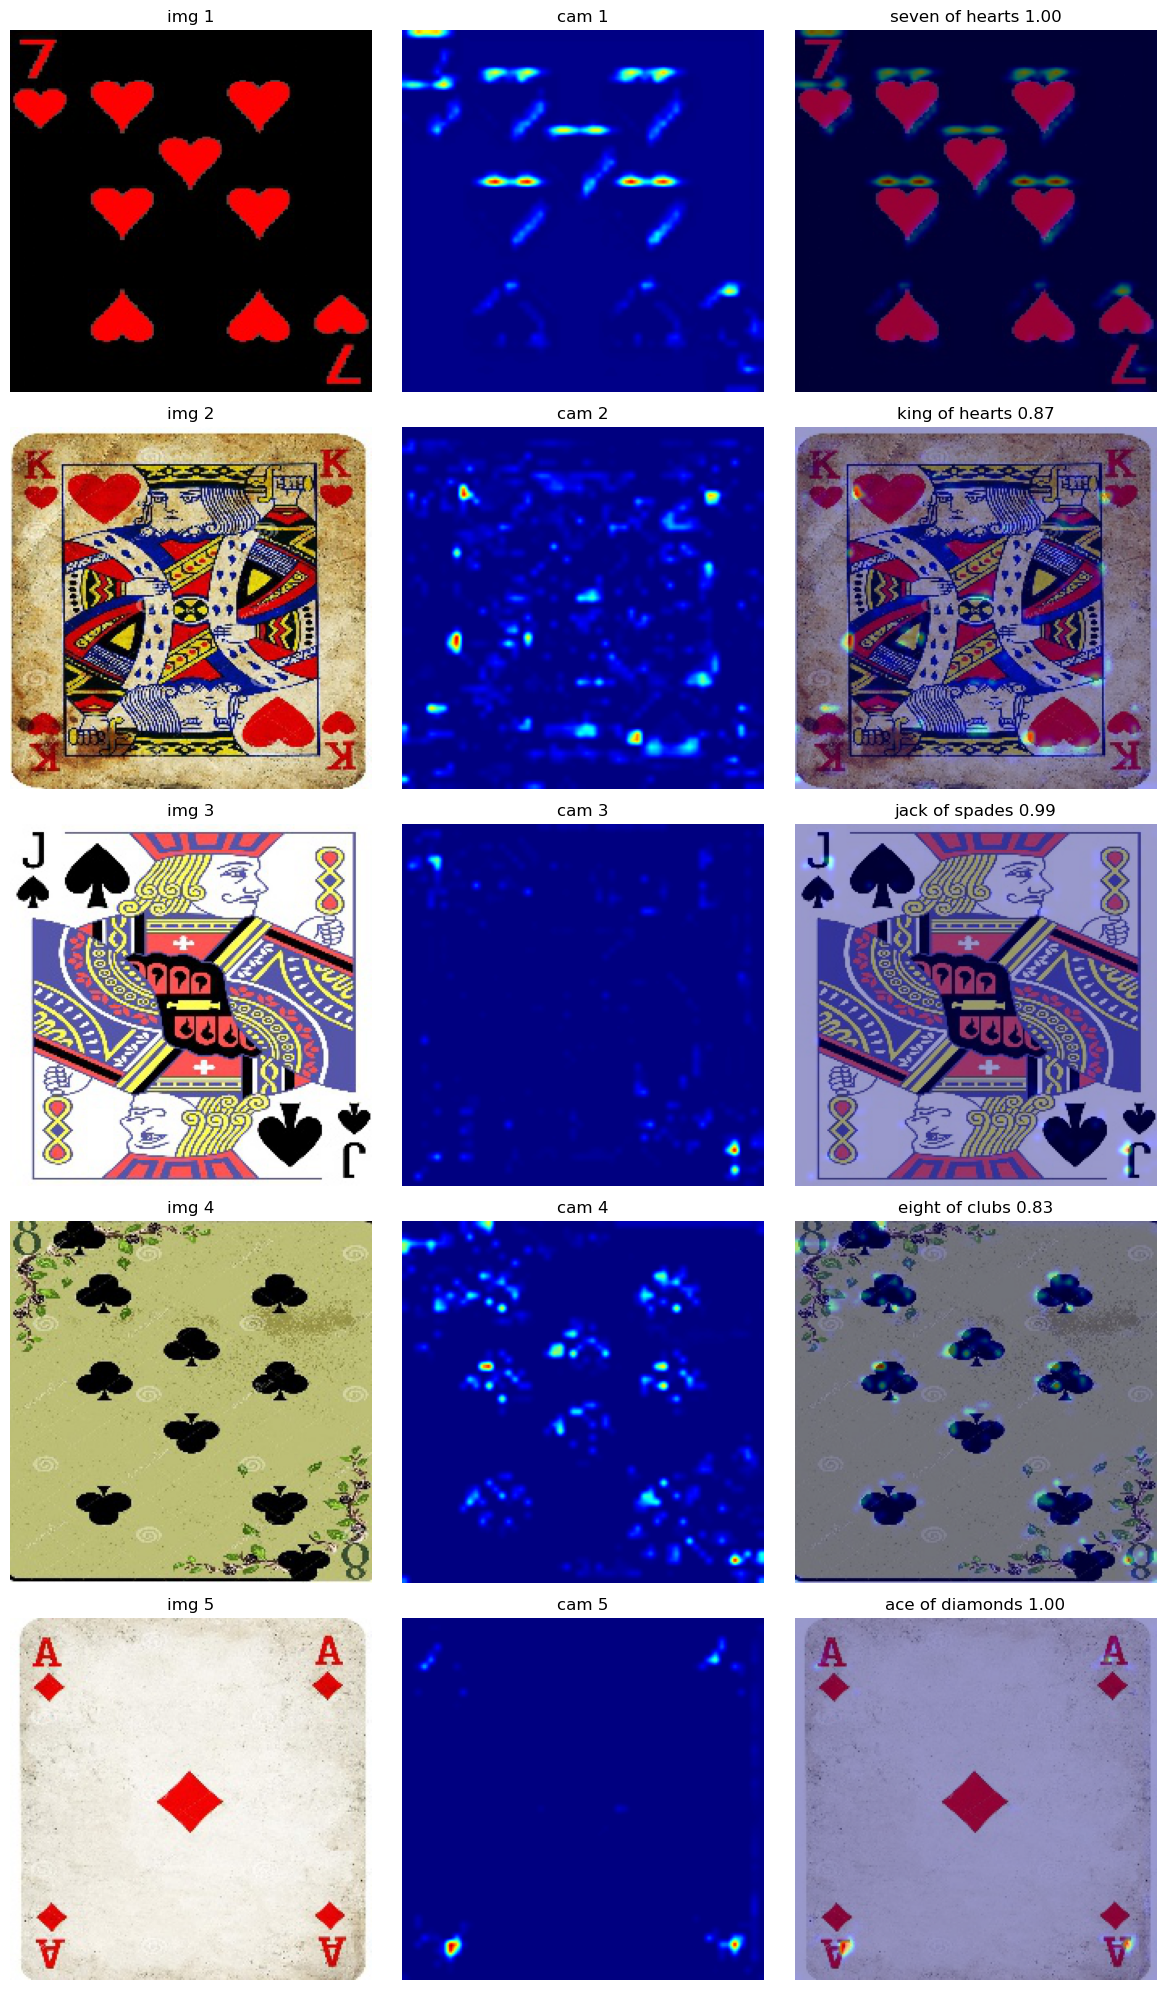

In [50]:
def ensure_model_called(model, sample_batch):
    try:
        if model.inputs:
            return
    except Exception:
        pass
    _ = model(sample_batch, training=False)


def make_gradcam_heatmap_sequential(model, img_array, target_layer_name="conv2d_2"):
    ensure_model_called(model, img_array)

    target_idx = None
    for i, layer in enumerate(model.layers):
        if layer.name == target_layer_name:
            target_idx = i
            break

    if target_idx is None:
        raise ValueError(f"Nie znaleziono warstwy {target_layer_name}")

    x = img_array

    with tf.GradientTape() as tape:
        for i in range(target_idx + 1):
            x = model.layers[i](x, training=False)

        conv_outputs = x
        tape.watch(conv_outputs)

        for i in range(target_idx + 1, len(model.layers)):
            x = model.layers[i](x, training=False)

        predictions = x
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    if grads is None:
        raise ValueError("Gradients are None")

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)
    heatmap = tf.maximum(heatmap, 0)

    max_val = tf.reduce_max(heatmap)
    if float(max_val) > 0:
        heatmap = heatmap / max_val

    return heatmap.numpy(), int(pred_index.numpy()), float(predictions[0][pred_index].numpy())


NUM_EXAMPLES = 5
TARGET_LAYER_NAME = "conv2d_2"

sample_analysis_paths = test_df.sample(NUM_EXAMPLES, random_state=SEED)["filepath"].tolist()

print("target conv:", TARGET_LAYER_NAME)
print("Wybrane pliki:")
for p in sample_analysis_paths:
    print(p)

fig, axes = plt.subplots(NUM_EXAMPLES, 3, figsize=(12, 4 * NUM_EXAMPLES))

if NUM_EXAMPLES == 1:
    axes = np.array([axes])

for row_idx, sample_analysis_path in enumerate(sample_analysis_paths):
    img, arr = preprocess_single_image(sample_analysis_path, analysis_preprocess)

    heatmap, pred_idx, pred_score = make_gradcam_heatmap_sequential(
        analysis_model,
        arr,
        target_layer_name=TARGET_LAYER_NAME,
    )

    heatmap_resized = cv2.resize(heatmap, (IMG_WIDTH, IMG_HEIGHT))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_rgb = cv2.cvtColor(
        cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET),
        cv2.COLOR_BGR2RGB,
    )
    overlay = cv2.addWeighted(np.array(img).astype(np.uint8), 0.6, heatmap_rgb, 0.4, 0)

    axes[row_idx, 0].imshow(img)
    axes[row_idx, 0].axis("off")
    axes[row_idx, 0].set_title(f"img {row_idx + 1}")

    axes[row_idx, 1].imshow(heatmap_rgb)
    axes[row_idx, 1].axis("off")
    axes[row_idx, 1].set_title(f"cam {row_idx + 1}")

    axes[row_idx, 2].imshow(overlay)
    axes[row_idx, 2].axis("off")
    axes[row_idx, 2].set_title(f"{idx_to_class[pred_idx]} {pred_score:.2f}")

plt.tight_layout()
plt.savefig(PLOTS_DIR / "gradcam.png", dpi=140, bbox_inches="tight")
plt.show()

## 25. Bledne predykcje

misclassified: 34 / 265


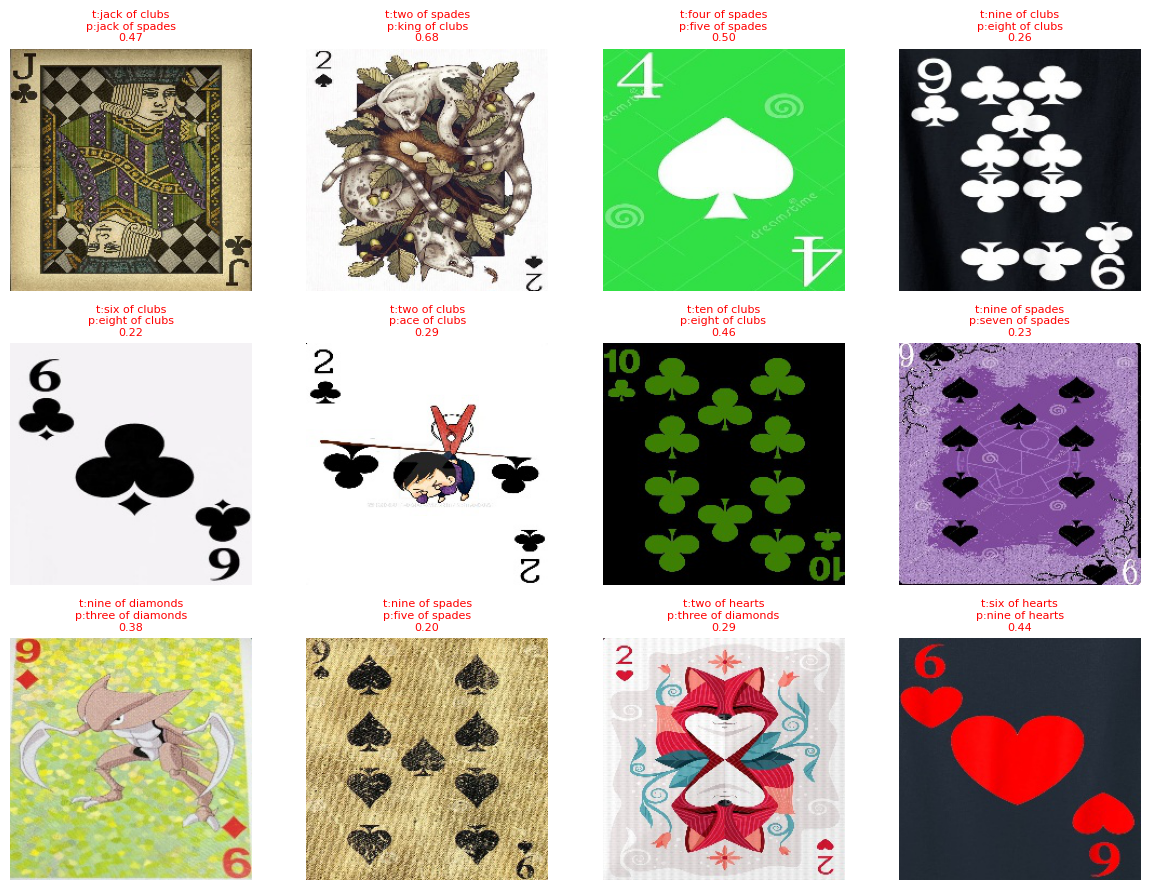

In [35]:
mis_idx = np.where(y_pred != y_true)[0]
print("misclassified:", len(mis_idx), "/", len(y_true))

if len(mis_idx) > 0:
    show_idx = np.random.choice(mis_idx, size=min(12, len(mis_idx)), replace=False)
    fig, axes = plt.subplots(3, 4, figsize=(12, 9))
    axes = axes.ravel()

    for ax, idx in zip(axes, show_idx):
        img_path = analysis_test_gen.filepaths[idx]
        img = load_img(img_path, target_size=IMG_SIZE)
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(
            f"t:{idx_to_class[y_true[idx]]}\np:{idx_to_class[y_pred[idx]]}\n{predictions[idx][y_pred[idx]]:.2f}",
            fontsize=8,
            color="red",
        )

    for i in range(len(show_idx), len(axes)):
        axes[i].axis("off")

    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "misclassified.png", dpi=140, bbox_inches="tight")
    plt.show()

## 26. Krotkie wnioski

In [36]:
best_cnn_val = float(np.max(best_cnn_history.history["val_accuracy"]))
best_transfer_row = transfer_df.iloc[0] if not transfer_df.empty else None
best_transfer_text = (
    f"{best_transfer_row['name']} val={best_transfer_row['best_val_acc']:.4f}"
    if best_transfer_row is not None
    else "brak"
)

print("Najwazniejsze obserwacje:")
print(f"1. Szukanie architektury na probce ma sens, bo pozwala szybko odrzucic slabe CNN i zostawic najlepszy uklad do pelnego treningu.")
print(f"2. Najlepszy CNN po pelnym treningu uzyskal val={best_cnn_val:.4f}.")
print(f"3. Najlepszy transfer learning: {best_transfer_text}.")
print("4. Test byl uzyty dopiero na koncu.")
print("5. Dla 8 GB VRAM bezpieczne sa lekkie modele i trening pojedynczo.")

Najwazniejsze obserwacje:
1. Szukanie architektury na probce ma sens, bo pozwala szybko odrzucic slabe CNN i zostawic najlepszy uklad do pelnego treningu.
2. Najlepszy CNN po pelnym treningu uzyskal val=0.8906.
3. Najlepszy transfer learning: EfficientNetB0 val=0.8792.
4. Test byl uzyty dopiero na koncu.
5. Dla 8 GB VRAM bezpieczne sa lekkie modele i trening pojedynczo.


## 27. Koniec

In [29]:
# del analysis_model
# del analysis_test_gen
# gc.collect()

# print("Done")
# print("Results:", RESULTS_DIR)

Done
Results: /home/chemik/studia/ggsn/agh_ggsn/ex2/results
